In [ ]:
import marimo as mo

In Bayesian optimization, the goal is to optimize a blackbox function, $f$. In our case, this function takes inputs of
$$
D = \{n, u_1, \ell_1, u_2, \ell_2, \cdots, u_k, \ell_k \}
$$

where

- $D$ is the design (an $n$-tuple set),
- $n$ is the sample size at each analysis point (total for both groups),
- $u_1$ and $\ell_1$ are the upper and lower bounds for the first stage, and
- $k$ is the total number of stages

and outputs several values of interest, $T$ (an $m$-tuple set), including (but not limited to)

- $\alpha$, the type I error
- $\beta$, the type II error
- $\mathbb{E}[N \, | \, \boldsymbol{\delta}]$, the expected sample size (ESS) $N$ over a range of differences, $\delta$, between groups $\boldsymbol{\delta} = \{\delta_1, \delta_2, \dots, \delta_j \}$

Above, $N = k*n$ and

The expected sample size is calculated across a set of possible true treatment effects $\boldsymbol{\delta} = \{\delta_1, \delta_2, \dots, \delta_j \}$ as a function of the design elements $D$: (1) number of analyses $\{1, 2, \dots, k\}$, (2) number of patients at each analysis $\mathbf{n} = \{n_1, n_2, \dots, n_k\}$, and (3) the upper and lower bounds $\mathbf{u} = (u_1, u_2, \dots, u_k)$ and $\boldsymbol{\ell} = (\ell_1, \ell_2, \dots, \ell_k)$.

It is calculated as
$$
\mathbb{E}[N \, | \, \boldsymbol{\delta}]=\sum_{i=1}^k n_i P(\text{trial stops after analysis }i \, | \, \boldsymbol{\delta})
$$

In order to generated an optimized clinical trial design, the following steps must be followed:
1. Generate several feasible trial designs, $\boldsymbol{D}=\{D_1, D_2, \cdots, D_p\}$.
2. Generate the corresponding outputs, $\boldsymbol{T}=\{T_1, T_2, \cdots, T_p\}$.
3. Fit a Gaussian process regression model to estimate the blackbox function $f: D \to T$.
4. Perform a step of Bayesian optimization to find the next trial design of interest $D_i$.
5. Obtain the corresponding outputs that correspond to this design $T_i$.
6. Refit the Gaussian process regression model on the new data $n$-tuples $\{(\boldsymbol{D}, \boldsymbol{T}), (D_i, T_i)\}$

Repeat until termination policy is reached.

In order to generated an optimized clinical trial design, the following steps must be followed:

1. Generate several feasible trial designs, $\boldsymbol{D}=\{D_1, D_2, \cdots, D_p\}$.
2. Generate the corresponding outputs, $\boldsymbol{T}=\{T_1, T_2, \cdots, T_p\}$.
3. Fit a Gaussian process regression model to estimate the blackbox function $f: D \to T$.
4. Perform a step of Bayesian optimization to find the next trial design of interest $D_i$.
5. Obtain the corresponding outputs that correspond to this design $T_i$.
6. Refit the Gaussian process regression model on the new data $n$-tuples $\{(\boldsymbol{D}, \boldsymbol{T}), (D_i, T_i)\}$

Repeat until termination policy is reached.

In all of the below runs, the following was true.

**The data presented below were generated using the following settings:**
- 3-stage design
- Target $\alpha = 0.05$
- Target $\beta = 0.1$, or power of 0.9
- Clinically meaningful difference, $\delta=1$
- Assumed variance, $\sigma^2=3$

**Objective function (loss):**
$$
\mathcal{L}(T_i,\mu) =\mu (\alpha' - \alpha)^2 + \mu(\beta' - \beta)^2 + \frac{\max\big(\mathbb{E}[N \, | \, \boldsymbol{\delta}]\big)}{\mu}
$$
where:
- $T_i$ is a vector that contains the design's calculated type I and type II error, and the per stage N, that is, $T_i=\{\alpha',\beta',N\}$.
- $\mu$ is the single stage sample size for the design.
- $\alpha$ is the target type I error.
- $\beta$ is the target type II error.
- $\mathbb{E}[N \, | \, \boldsymbol{\delta}]$ is defined above.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# group sequential design assessment imports
from py_group_sequential_designs import generate_boundaries as bd
from py_group_sequential_designs import feasibility_penalty as fp
from py_group_sequential_designs import boundary_manipulations as fmt_bd
from py_group_sequential_designs import function_to_minimize as fn_min
from py_group_sequential_designs import generate_gpr_input as gen_input
from py_group_sequential_designs import simulate as sim
from py_group_sequential_designs import sample_size as ss

In [ ]:
# get colors for plotting
colors = plt.cm.tab20.colors

# February data

# Small box

## Bayesian optimization settings

- GPR kernel was Matern52
- Upper bound of search space was `[ 3,  2.9,  2.8,  2.7, 2.6, 60]`
- Lower bound of search space was `[-3, -2.9, -2.8, -2.7, -2.6, 5]`
- `acquisition_rule = EfficientGlobalOptimization`

## Import the data

In [ ]:
small_box_feb_bounds = pd.read_csv(
    filepath_or_buffer="/tf/2026-02-t12/small_box_boundaries.csv",
    header=0,
    names=["upper1","upper2","upper3","lower1","lower2","n"]
)

In [ ]:
small_box_feb_obj_f = pd.read_csv(
    filepath_or_buffer="/tf/2026-02-t12/small_box_penalty.csv",
    header=0,
    names=["obj_f"]
)

In [ ]:
small_box_feb = pd.concat([small_box_feb_bounds, small_box_feb_obj_f], axis=1)

## Check for monotonicity

In [ ]:
_monotonic = []

for _i in range(small_box_feb.shape[0]):
    _bounds = small_box_feb.loc[_i, ["upper1","upper2","upper3","lower1","lower2","n"]]
    _bounds_arr = np.array(_bounds)
    _monotonic.append(fmt_bd.check_monotonicity(n_analyses = 3, bounds = _bounds_arr))

small_box_feb["monotonic"] = _monotonic

## Analyze only the monotonic bounds

In [ ]:
small_box_feb_remove_known = small_box_feb.iloc[3:]

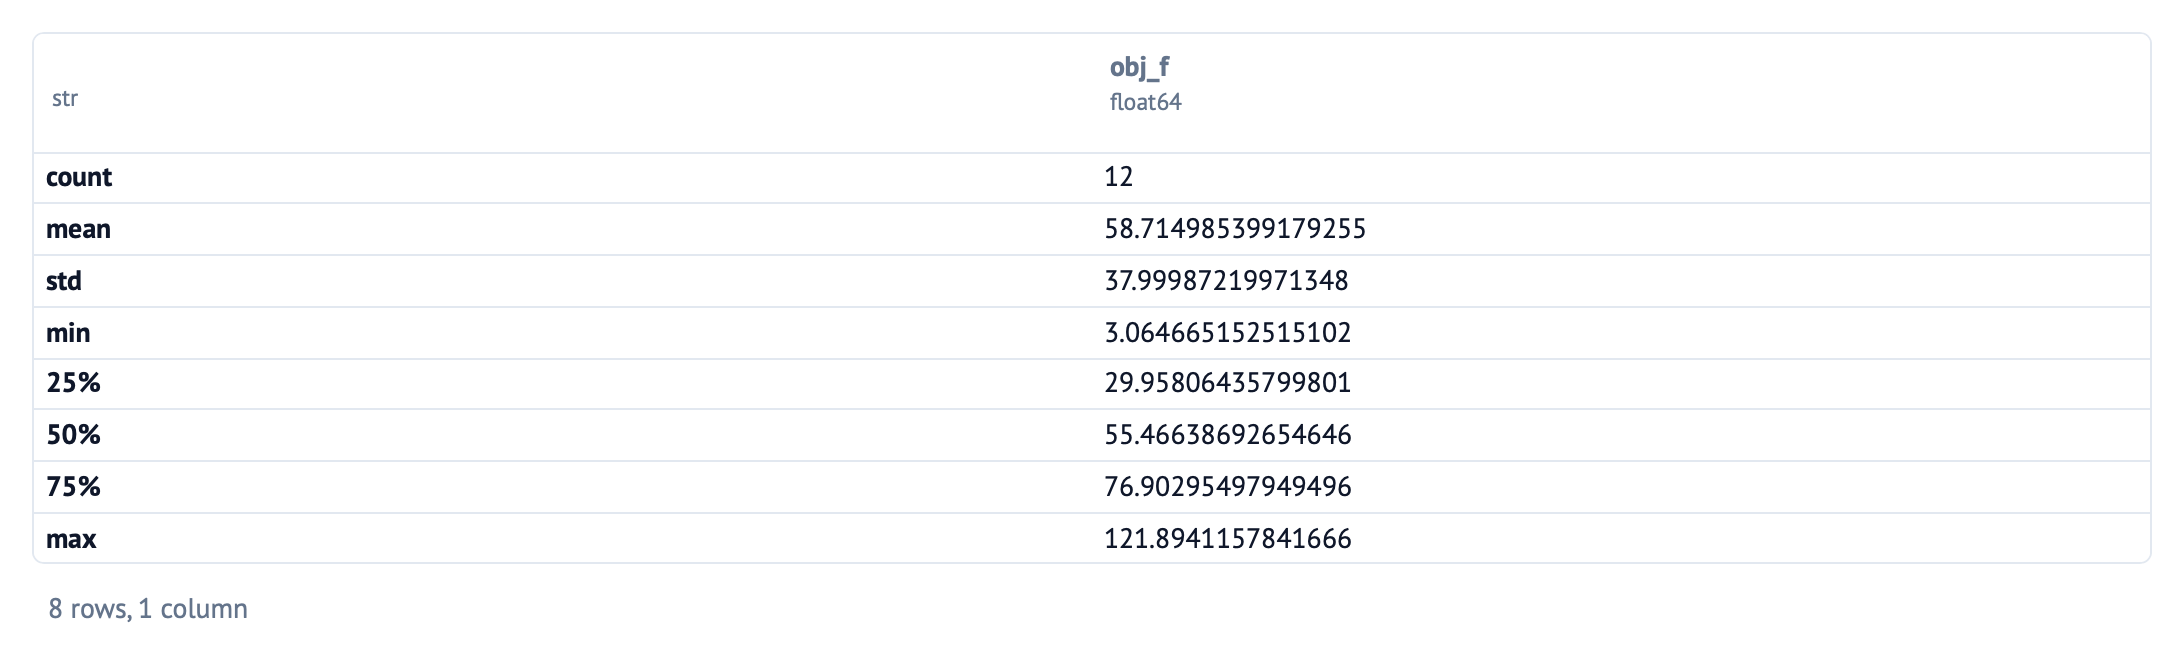

In [ ]:
small_box_feb_remove_known[small_box_feb_remove_known["monotonic"] == True]["obj_f"].describe()

### Of 1000 runs, 12 monotonic, minimum penalty 3.06 - 121

In [ ]:
mo.md(f"""
### {np.round(12/1000*100, decimals=2)}%
""")

<span class="markdown prose dark:prose-invert contents"><h3 id="12">1.2%</h3></span>

# Big box

## Bayesian optimization settings

- GPR kernel was Matern52
- Upper bound of search space was `[ 6,  6,  6,  6,  6, 60]`
- Lower bound of search space was `[-6, -6, -6, -6, -6, 2]`
- `acquisition_rule = EfficientGlobalOptimization`

## Import the data

In [ ]:
big_box_feb_bounds = pd.read_csv(
    filepath_or_buffer="/tf/2026-02-t12/box6-6-2-60_boundaries.csv",
    header=0,
    names=["upper1","upper2","upper3","lower1","lower2","n"]
)

In [ ]:
big_box_feb_obj_f = pd.read_csv(
    filepath_or_buffer="/tf/2026-02-t12/box6-6-2-60_penalty.csv",
    header=0,
    names=["obj_f"]
)

In [ ]:
big_box_feb = pd.concat([big_box_feb_bounds, big_box_feb_obj_f], axis=1)

## Check for monotonicity

In [ ]:
_monotonic = []

for _i in range(big_box_feb.shape[0]):
    _bounds = big_box_feb.loc[_i, ["upper1","upper2","upper3","lower1","lower2","n"]]
    _bounds_arr = np.array(_bounds)
    _monotonic.append(fmt_bd.check_monotonicity(n_analyses = 3, bounds = _bounds_arr))

big_box_feb["monotonic"] = _monotonic

## Analyze only the monotonic bounds

In [ ]:
big_box_feb_remove_known = big_box_feb.iloc[3:].reset_index()

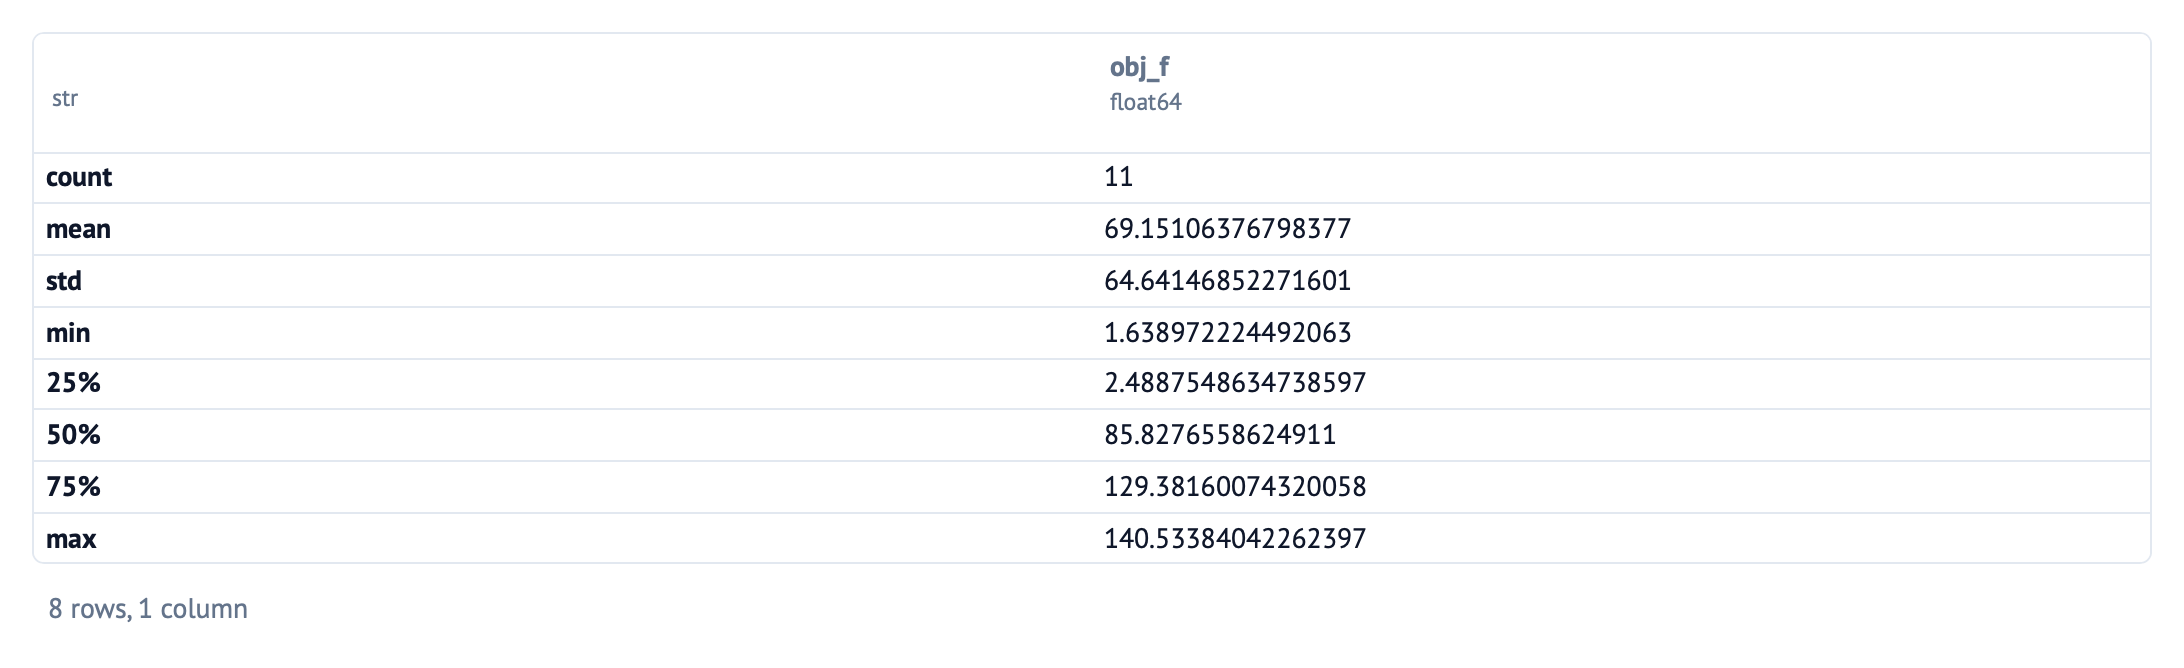

In [ ]:
big_box_feb_remove_known[big_box_feb_remove_known["monotonic"] == True]["obj_f"].describe()

### Of 1000 runs, 11 monotonic, minimum penalty 1.64 - 2.73

In [ ]:
mo.md(rf"""
### {np.round(11/1000*100, decimals=2)}%
""")

<span class="markdown prose dark:prose-invert contents"><h3 id="11">1.1%</h3></span>

In [ ]:
big_box_feb_best = big_box_feb_remove_known[
    (big_box_feb_remove_known["monotonic"] == True) & (big_box_feb_remove_known["obj_f"] < 3)
].reset_index()

In [ ]:
big_box_feb_best.shape

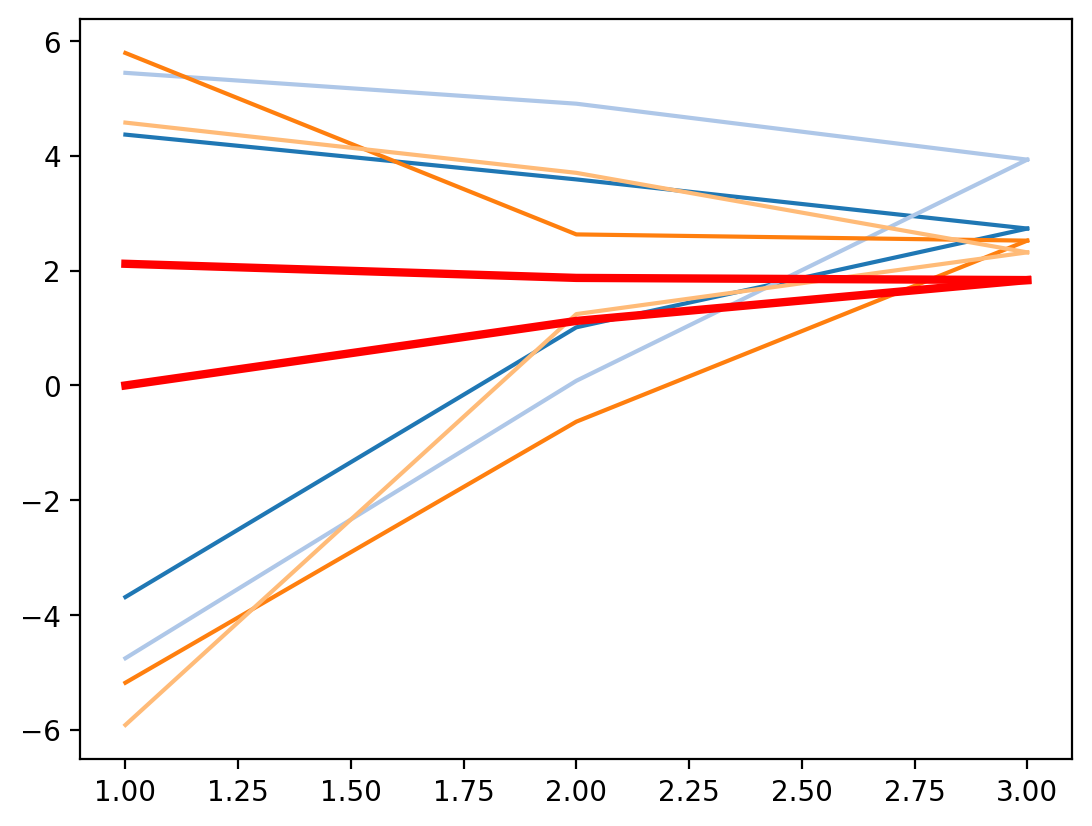

In [ ]:
_fig, _ax = plt.subplots()

for _i in range(big_box_feb_best.shape[0]):
    _ax.plot([1,2,3], big_box_feb_best.loc[_i, ["upper1", "upper2", "upper3"]], color = colors[_i])
    _ax.plot([1,2,3], big_box_feb_best.loc[_i, ["lower1", "lower2","upper3"]], color = colors[_i])

_ax.plot([1,2,3], [2.11957748, 1.87345951, 1.83560794], lw=3, color="red")
_ax.plot([1,2,3], [6.28553399e-16, 1.12407571e+00, 1.83560794e+00], lw=3, color="red")

_fig

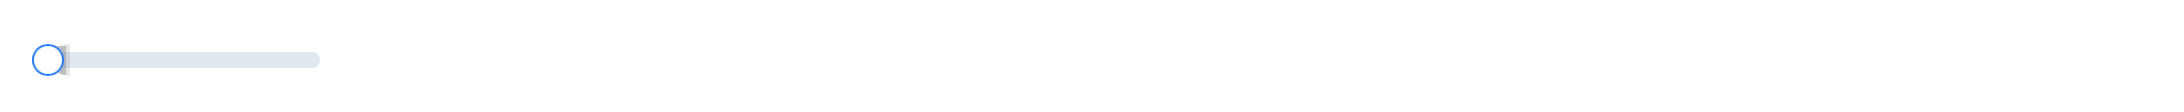

In [ ]:
slider1 = mo.ui.slider(start=0, stop=big_box_feb_best.shape[0]-1, step=1)
slider1

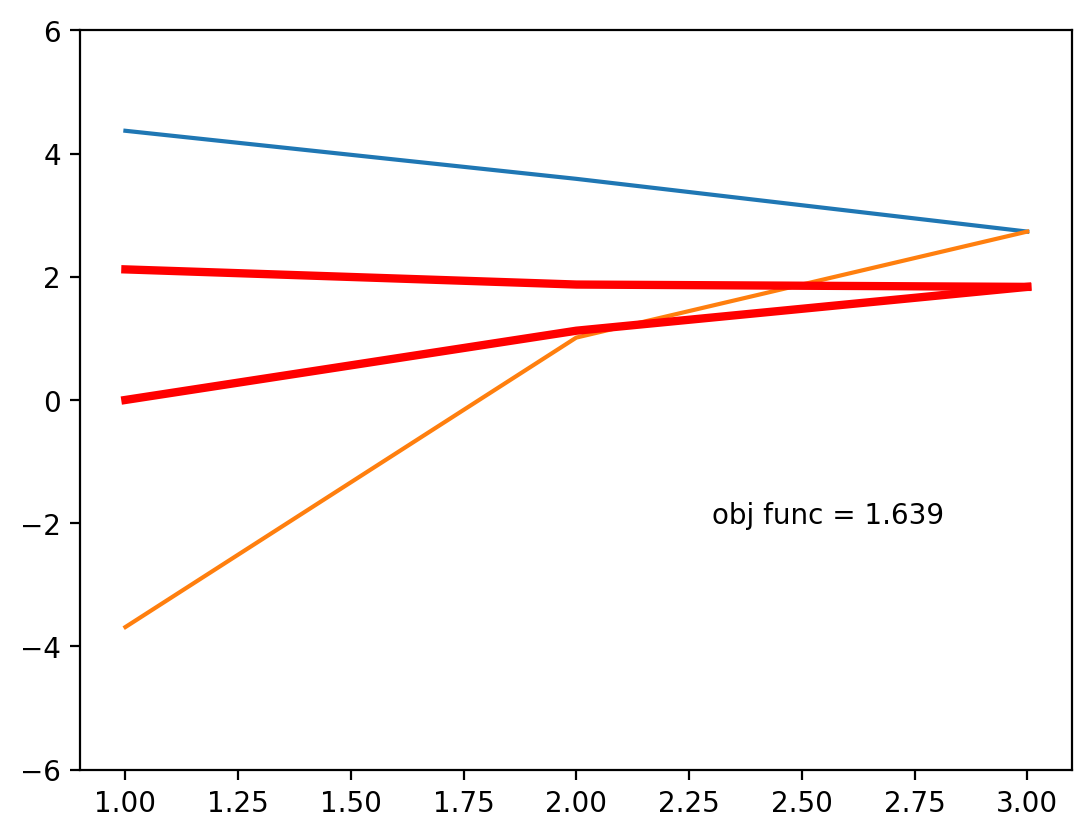

In [ ]:
plt.plot([1,2,3], big_box_feb_best.loc[slider1.value, ["upper1", "upper2", "upper3"]])
plt.plot([1,2,3], big_box_feb_best.loc[slider1.value, ["lower1", "lower2","upper3"]])

plt.plot([1,2,3], [2.11957748, 1.87345951, 1.83560794], lw=3, color="red")
plt.plot([1,2,3], [6.28553399e-16, 1.12407571e+00, 1.83560794e+00], lw=3, color="red")

plt.text(2.3, -2, str("obj func = ")+str(big_box_feb_best.loc[slider1.value, "obj_f"].round(3)))
plt.ylim(-6, 6)

plt.show()

# March data

# Big box with monotonic penalty

## Bayesian optimization settings

- Penalty modified to include $\mathcal{L}=25$ if not monotonic, else same as above.
- GPR kernel was Matern52
- Upper bound of search space was `[ 3, 3, 3, 3, 3, 30]`
- Lower bound of search space was `[-3,-3,-3,-3,-3, 10]`
- `acquisition_rule = EfficientGlobalOptimization`

## Import the data

In [ ]:
big_box_march = pd.read_csv(
    filepath_or_buffer="/tf/2026-03-t15/data/big_box_monotonicity.csv",
    header=0,
    names=["upper1","upper2","upper3","lower1","lower2","n", "obj_f"]
)

## Check for monotonicity

In [ ]:
_monotonic = []

for _i in range(big_box_march.shape[0]):
    _bounds = big_box_march.loc[_i, ["upper1","upper2","upper3","lower1","lower2","n"]]
    _bounds_arr = np.array(_bounds)
    _monotonic.append(fmt_bd.check_monotonicity(n_analyses = 3, bounds = _bounds_arr))

big_box_march["monotonic"] = _monotonic

## Analyze the monotonic bounds

In [ ]:
big_box_march_remove_known = big_box_march.iloc[3:]

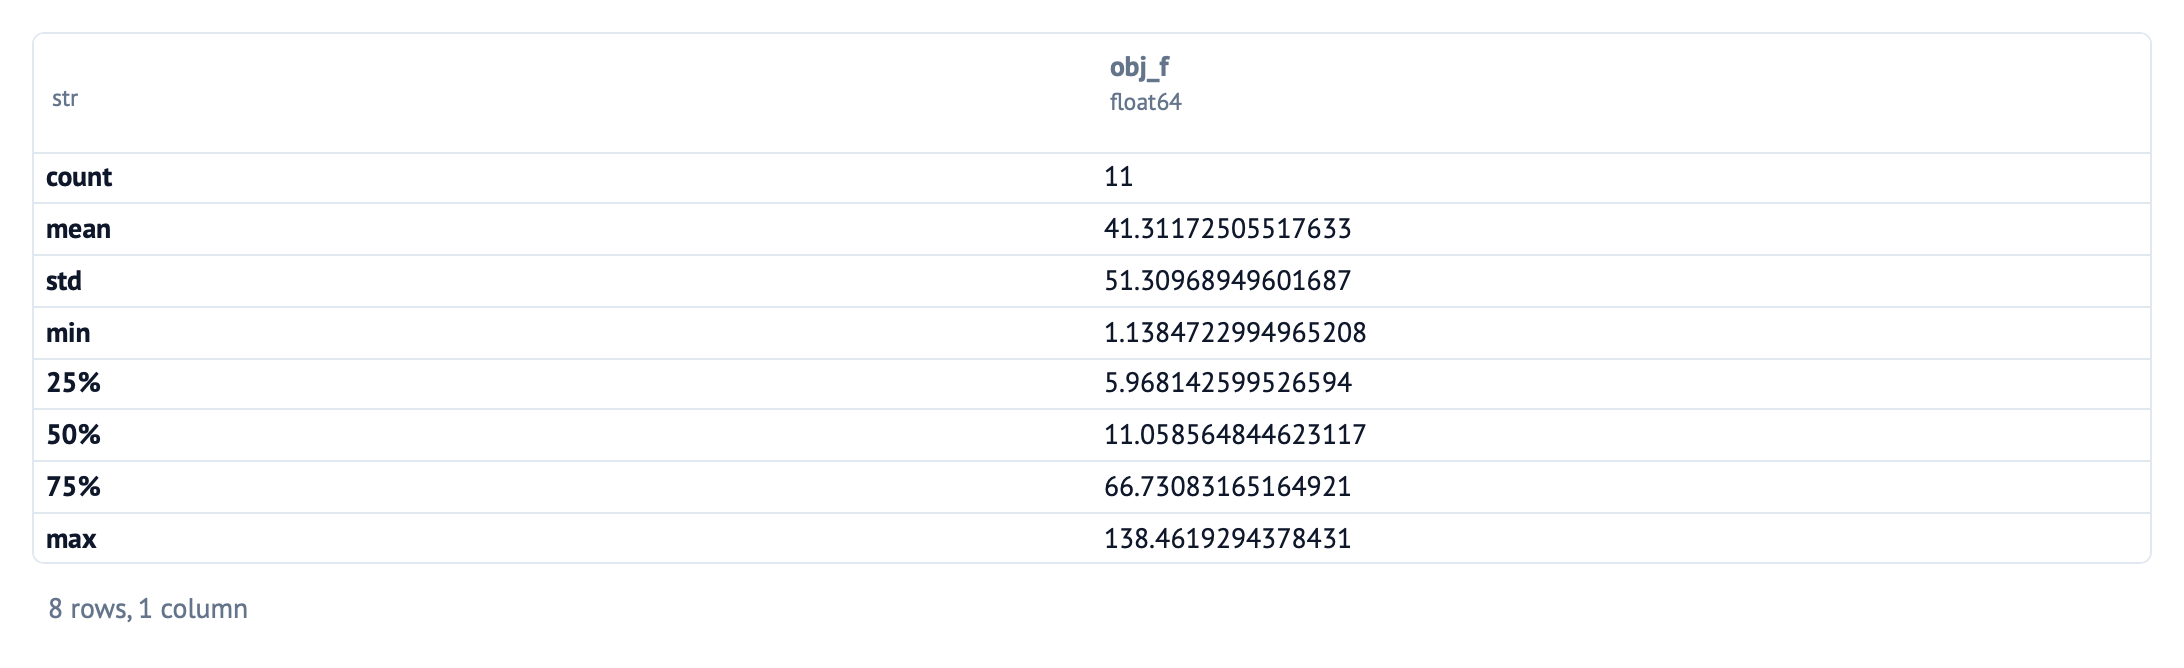

In [ ]:
big_box_march_remove_known[big_box_march_remove_known["monotonic"] == True]["obj_f"].describe()

### Of 1790 runs, 11 monotonic, minimum penalty 1.14 - 138

In [ ]:
mo.md(f"""
### {np.round(11/1790*100, decimals=2)}%
""")

<span class="markdown prose dark:prose-invert contents"><h3 id="061">0.61%</h3></span>

In [ ]:
big_box_march_best = big_box_march_remove_known[
    (big_box_march_remove_known["monotonic"] == True) & (big_box_march_remove_known["obj_f"] < 3)
].reset_index()

In [ ]:
big_box_march_best.shape

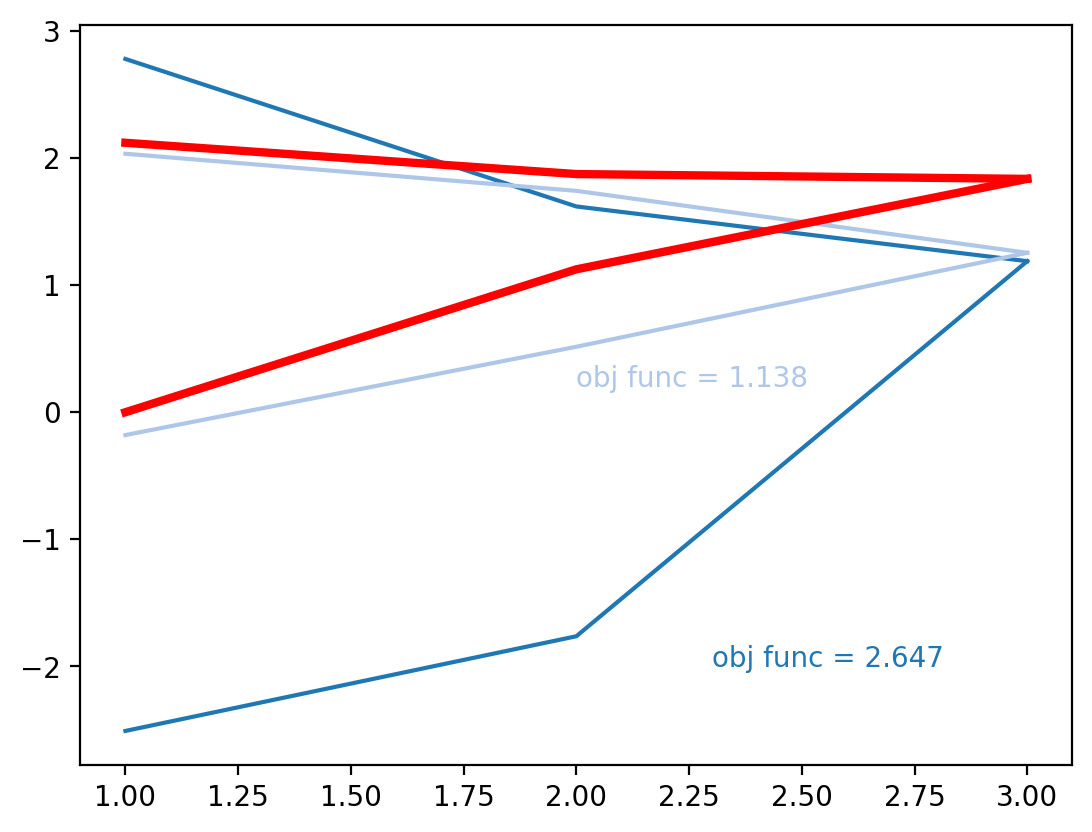

In [ ]:
_fig, _ax = plt.subplots()

for _i in range(big_box_march_best.shape[0]):
    _ax.plot([1,2,3], big_box_march_best.loc[_i, ["upper1", "upper2", "upper3"]], color = colors[_i])
    _ax.plot([1,2,3], big_box_march_best.loc[_i, ["lower1", "lower2","upper3"]], color = colors[_i])

_ax.text(2.3, -2, str("obj func = ")+str(big_box_march_best.loc[0, "obj_f"].round(3)), color = colors[0])
_ax.text(2, 0.2, str("obj func = ")+str(big_box_march_best.loc[1, "obj_f"].round(3)), color = colors[1])
_ax.plot([1,2,3], [2.11957748, 1.87345951, 1.83560794], lw=3, color="red")
_ax.plot([1,2,3], [6.28553399e-16, 1.12407571e+00, 1.83560794e+00], lw=3, color="red")

_fig

# Pocock region with monotonicity

## Bayesian optimization settings

- Penalty modified to include $\mathcal{L}=25$ if not monotonic, else same as above.
- GPR kernel was Matern52
- Upper bound of search space was `[1.72998486,  1.72998486,  1.72998486, -2.25438538, -2.25438538, 10]`
- Lower bound of search space was `[2.25438538,  2.25438538,  2.25438538, -1.72998486, -1.72998486, 30]`
- `acquisition_rule = EfficientGlobalOptimization`

## Import the data

In [ ]:
pocock_mono = pd.read_csv(
    filepath_or_buffer="/tf/2026-03-t15/data/pocock_monotonicity.csv",
    header=0,
    names=["upper1","upper2","upper3","lower1","lower2","n", "obj_f"]
)

## Check for monotonicity

In [ ]:
_monotonic = []

for _i in range(pocock_mono.shape[0]):
    _bounds = pocock_mono.loc[_i, ["upper1","upper2","upper3","lower1","lower2","n"]]
    _bounds_arr = np.array(_bounds)
    _monotonic.append(fmt_bd.check_monotonicity(n_analyses = 3, bounds = _bounds_arr))

pocock_mono["monotonic"] = _monotonic

## Analyze the monotonic bounds

In [ ]:
pocock_mono_remove_known = pocock_mono.iloc[3:]

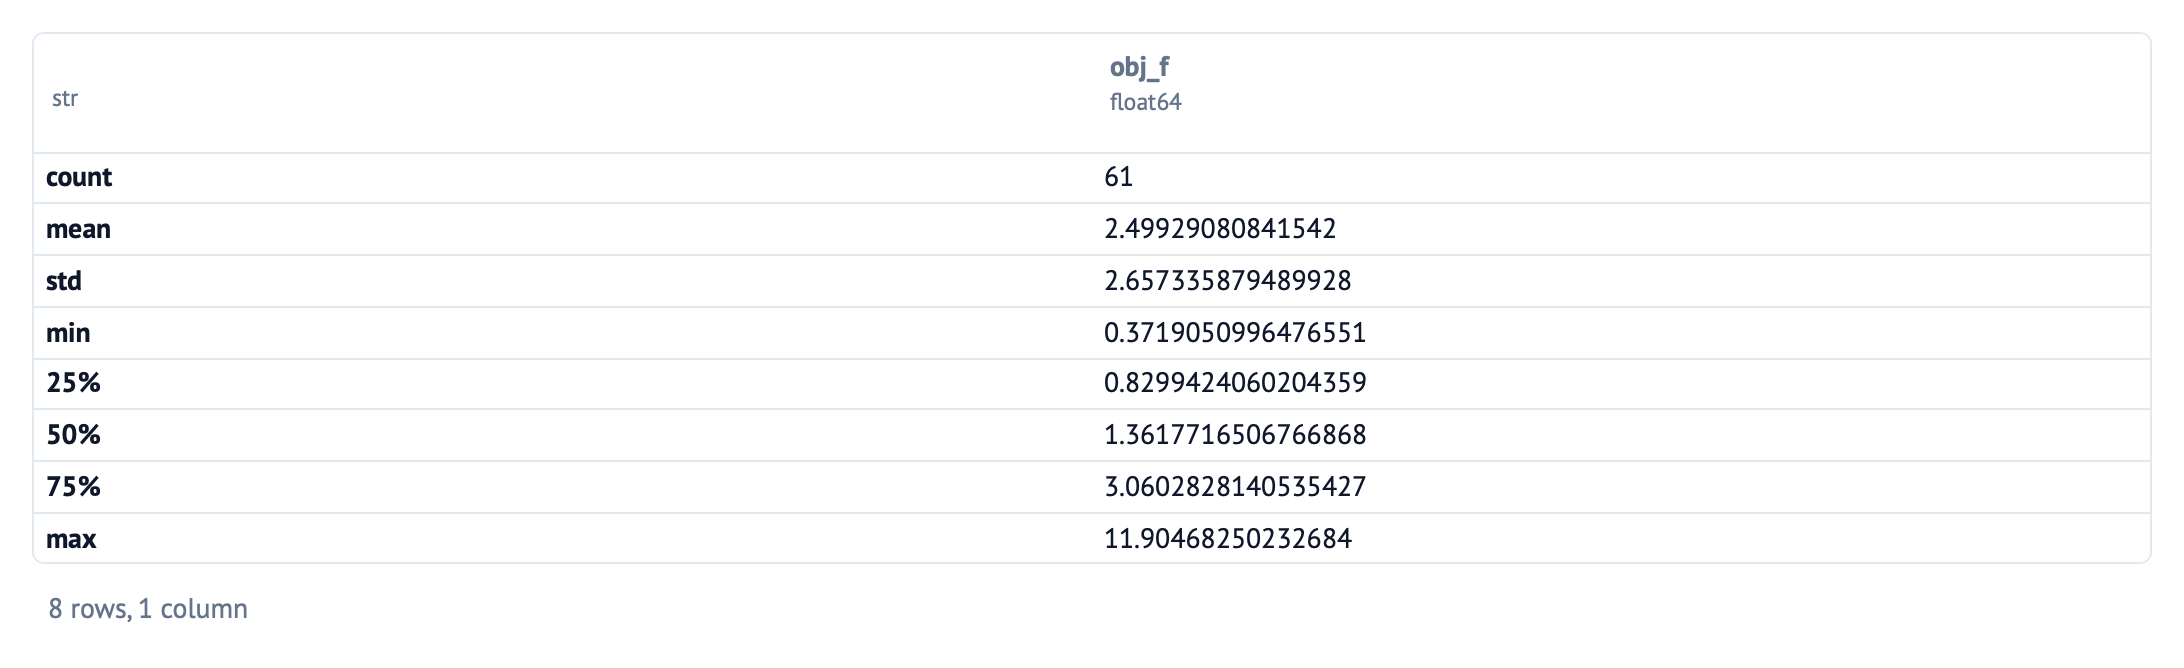

In [ ]:
pocock_mono_remove_known[pocock_mono_remove_known["monotonic"] == True]["obj_f"].describe()

### Of 700 runs, 61 monotonic, minimum penalty 0.372 - 11.9

In [ ]:
mo.md(rf"""
### {np.round(61/700*100, decimals=2)}%
""")

<span class="markdown prose dark:prose-invert contents"><h3 id="871">8.71%</h3></span>

In [ ]:
pocock_mono_best = pocock_mono_remove_known[
    (pocock_mono_remove_known["monotonic"] == True) & (pocock_mono_remove_known["obj_f"] < 0.5)
].reset_index()

In [ ]:
pocock_mono_best.shape

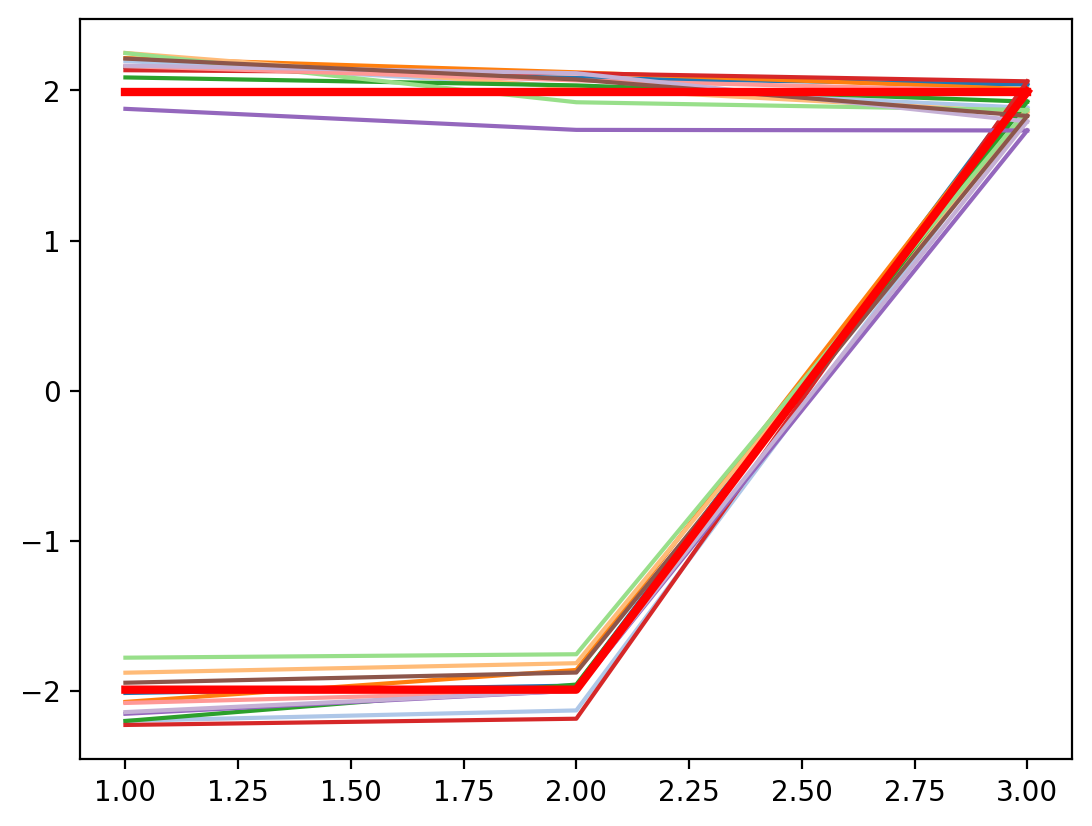

In [ ]:
_fig, _ax = plt.subplots()

for _i in range(pocock_mono_best.shape[0]):
    _ax.plot([1,2,3], pocock_mono_best.loc[_i, ["upper1", "upper2", "upper3"]], color = colors[_i])
    _ax.plot([1,2,3], pocock_mono_best.loc[_i, ["lower1", "lower2","upper3"]], color = colors[_i])

_ax.plot([1,2,3], [1.99218601, 1.99218601, 1.99218601], lw=3, color="red")
_ax.plot([1,2,3], [-1.99218601, -1.99218601, 1.99218601], lw=3, color="red")

_fig

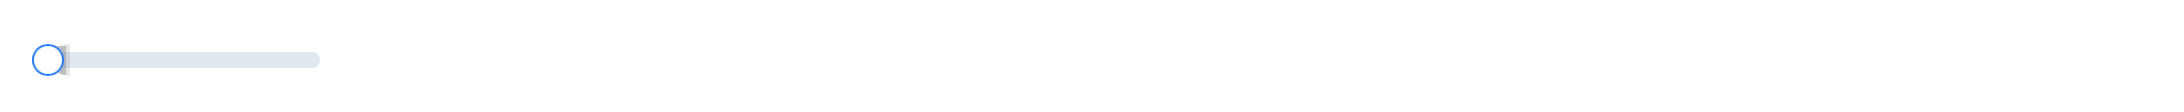

In [ ]:
slider2 = mo.ui.slider(start=0, stop=pocock_mono_best.shape[0]-1, step=1)
slider2

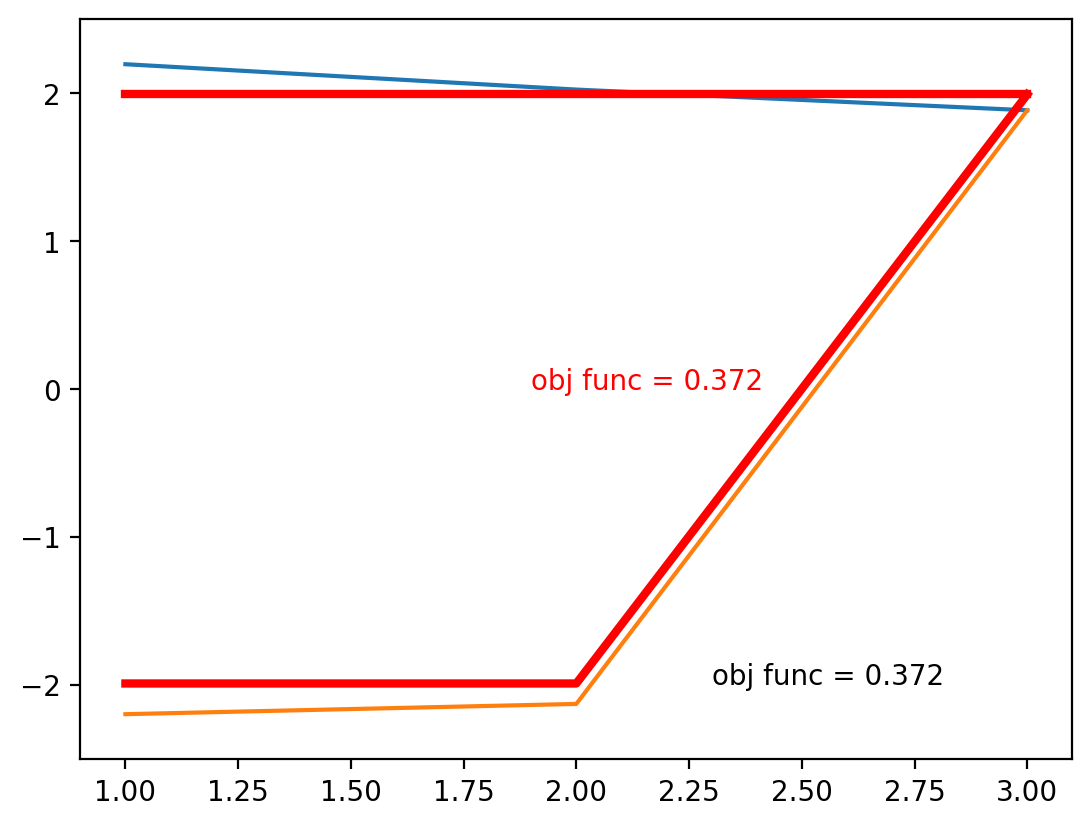

In [ ]:
plt.plot([1,2,3], pocock_mono_best.loc[slider2.value, ["upper1", "upper2", "upper3"]])
plt.plot([1,2,3], pocock_mono_best.loc[slider2.value, ["lower1", "lower2","upper3"]])

plt.plot([1,2,3], [1.99218601, 1.99218601, 1.99218601], lw=3, color="red")
plt.plot([1,2,3], [-1.99218601, -1.99218601, 1.99218601], lw=3, color="red")
plt.text(1.9, 0, str("obj func = ")+str(0.372), color = "red")

plt.text(2.3, -2, str("obj func = ")+str(pocock_mono_best.loc[slider2.value, "obj_f"].round(3)))

plt.ylim(-2.5, 2.5)

plt.show()

# Pocock region without monotonicity

## Bayesian optimization settings

- GPR kernel was Matern52
- Upper bound of search space was `[1.72998486,  1.72998486,  1.72998486, -2.25438538, -2.25438538, 10]`
- Lower bound of search space was `[2.25438538,  2.25438538,  2.25438538, -1.72998486, -1.72998486, 30]`
- `acquisition_rule = EfficientGlobalOptimization`

## Import the data

In [ ]:
pocock_no_mono = pd.read_csv(
    filepath_or_buffer="/tf/2026-03-t15/data/pocock_no_monotonicity.csv",
    header=0,
    names=["upper1","upper2","upper3","lower1","lower2","n", "obj_f"]
)

## Check for monotonicity

In [ ]:
_monotonic = []

for _i in range(pocock_no_mono.shape[0]):
    _bounds = pocock_no_mono.loc[_i, ["upper1","upper2","upper3","lower1","lower2","n"]]
    _bounds_arr = np.array(_bounds)
    _monotonic.append(fmt_bd.check_monotonicity(n_analyses = 3, bounds = _bounds_arr))

pocock_no_mono["monotonic"] = _monotonic

## Analyze the monotonic bounds

In [ ]:
pocock_no_mono_remove_known = pocock_no_mono.iloc[3:]

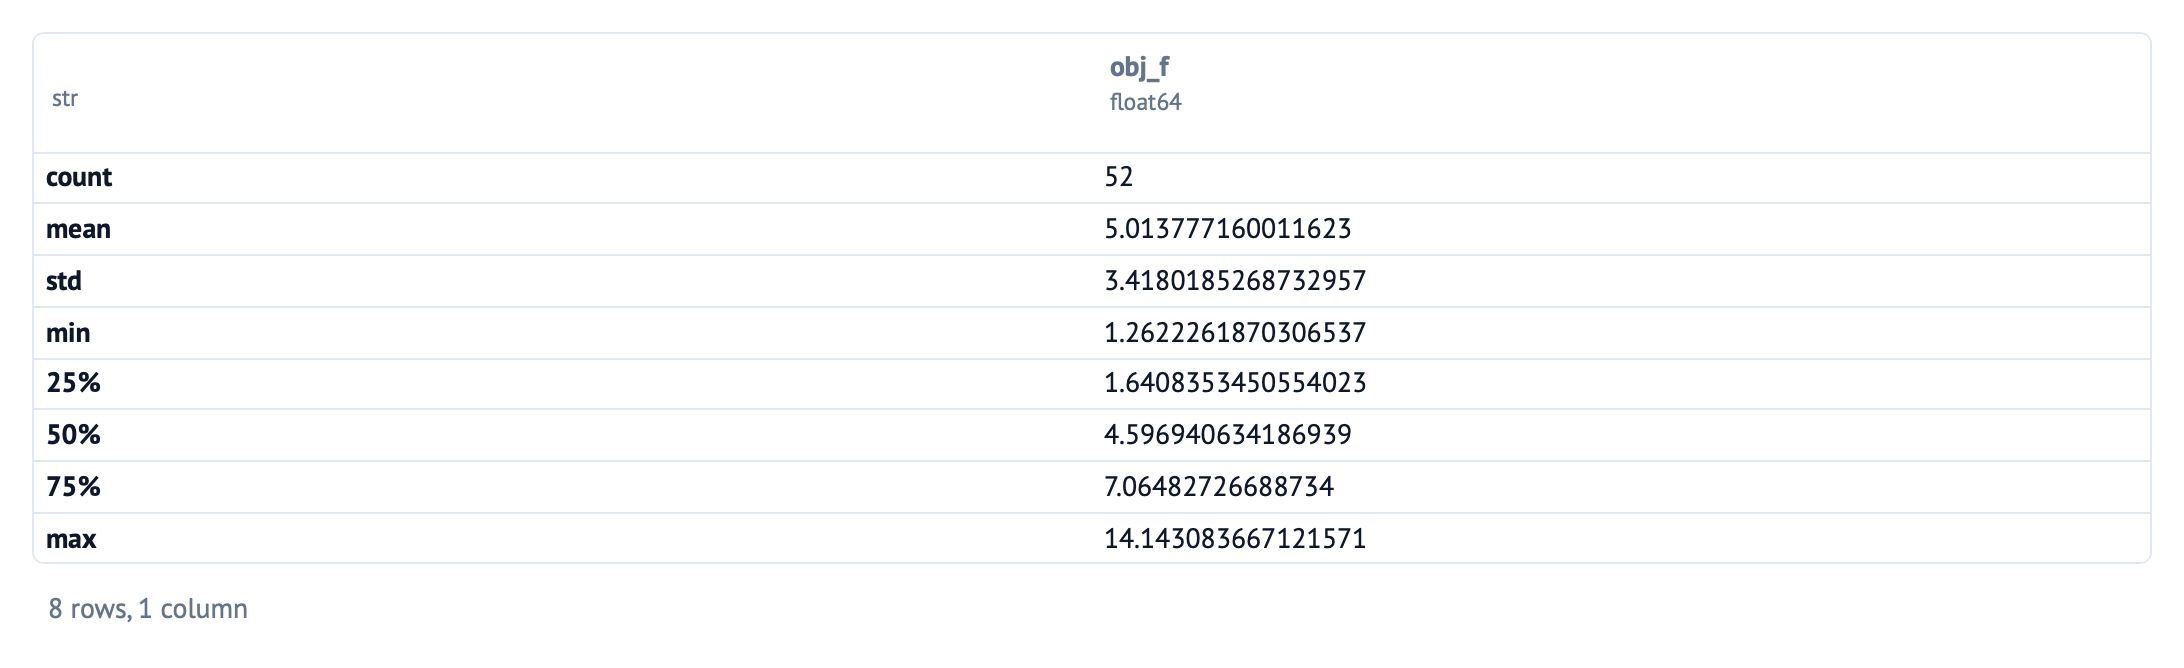

In [ ]:
pocock_no_mono_remove_known[pocock_no_mono_remove_known["monotonic"] == True]["obj_f"].describe()

### Of 700 runs, 52 monotonic, minimum penalty 1.26 - 14.1

In [ ]:
mo.md(rf"""
### {np.round(52/700*100, decimals=2)}%
""")

<span class="markdown prose dark:prose-invert contents"><h3 id="743">7.43%</h3></span>

# Separate upper and lower boxes - force monotonicity

## Bayesian optimization settings

- GPR kernel was Matern52
- Lower bound of search space was `[ 0, 0, 0, -3, -3, 10]`
- Upper bound of search space was `[ 3, 3, 3,  0,  0, 30]`
- `acquisition_rule = EfficientGlobalOptimization`

## Import the data

In [ ]:
separate_upper_lower = pd.read_csv(
    filepath_or_buffer="/tf/2026-03-t15/data/separate_upper_lower_box_monotonic.csv",
    header=0,
    names=["upper1","upper2","upper3","lower1","lower2","n", "obj_f"]
)

## Check for monotonicity

In [ ]:
_monotonic = []

for _i in range(separate_upper_lower.shape[0]):
    _bounds = separate_upper_lower.loc[_i, ["upper1","upper2","upper3","lower1","lower2","n"]]
    _bounds_arr = np.array(_bounds)
    _monotonic.append(fmt_bd.check_monotonicity(n_analyses = 3, bounds = _bounds_arr))

separate_upper_lower["monotonic"] = _monotonic

## Analyze the monotonic bounds

In [ ]:
separate_upper_lower_remove_known = separate_upper_lower.iloc[3:]

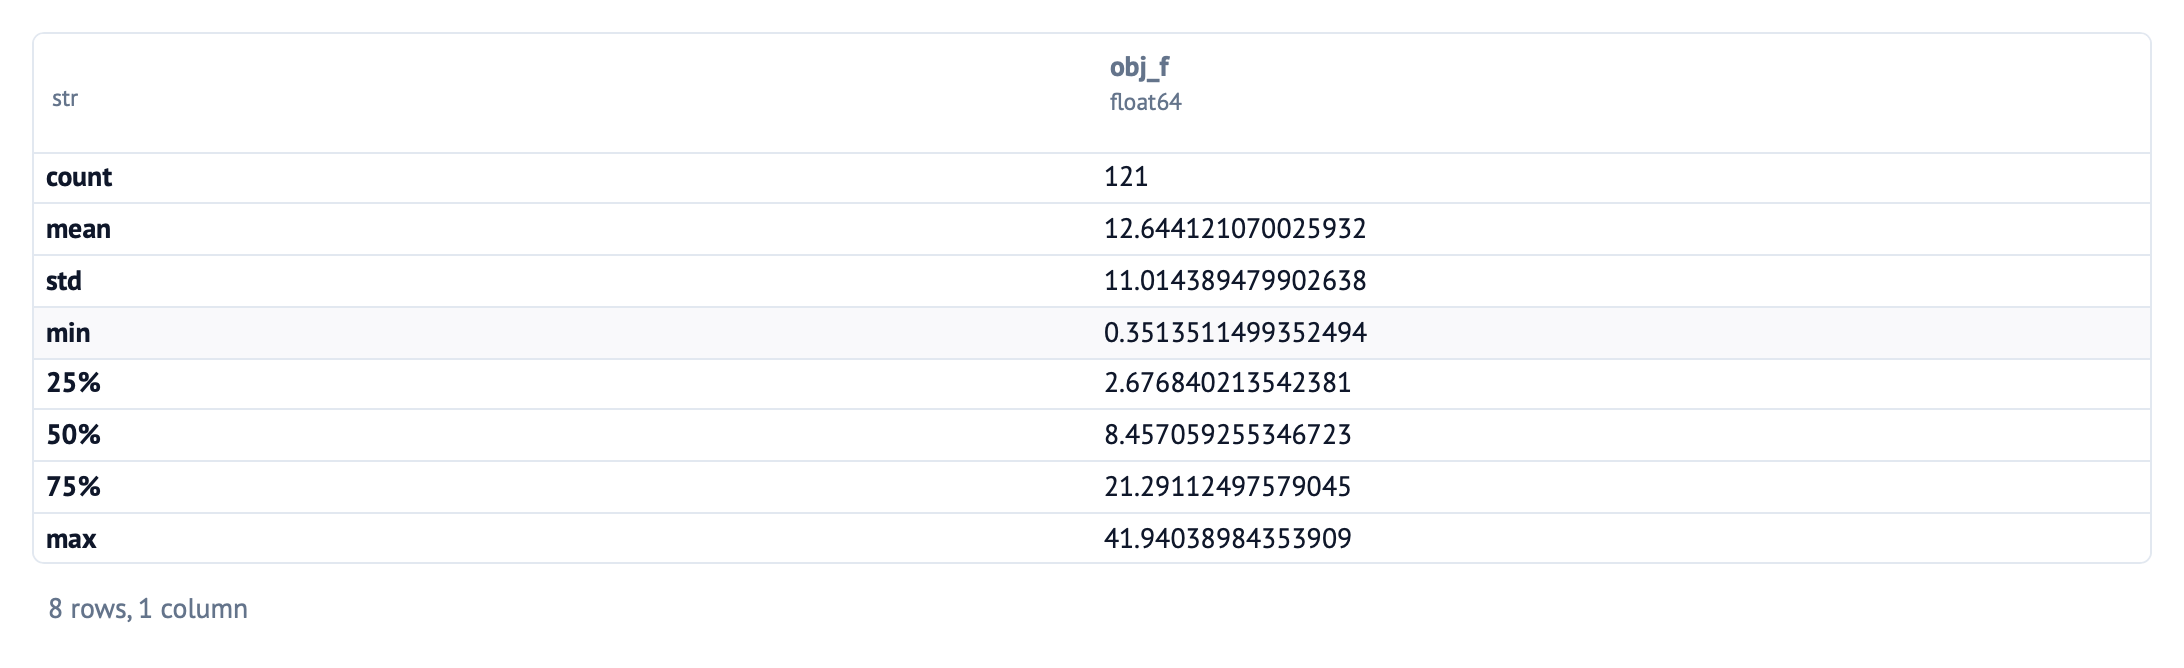

In [ ]:
separate_upper_lower_remove_known[separate_upper_lower_remove_known["monotonic"] == True]["obj_f"].describe()

### Of 1500 runs, 121 monotonic, minimum penalty 0.351 - 41.9

In [ ]:
mo.md(f"""
### {np.round(121/1500*100, decimals=2)}%
""")

<span class="markdown prose dark:prose-invert contents"><h3 id="807">8.07%</h3></span>

In [ ]:
separate_upper_lower_best = separate_upper_lower_remove_known[
    (separate_upper_lower_remove_known["monotonic"] == True) & (separate_upper_lower_remove_known["obj_f"] < 0.9)
].reset_index()

In [ ]:
separate_upper_lower_best.shape

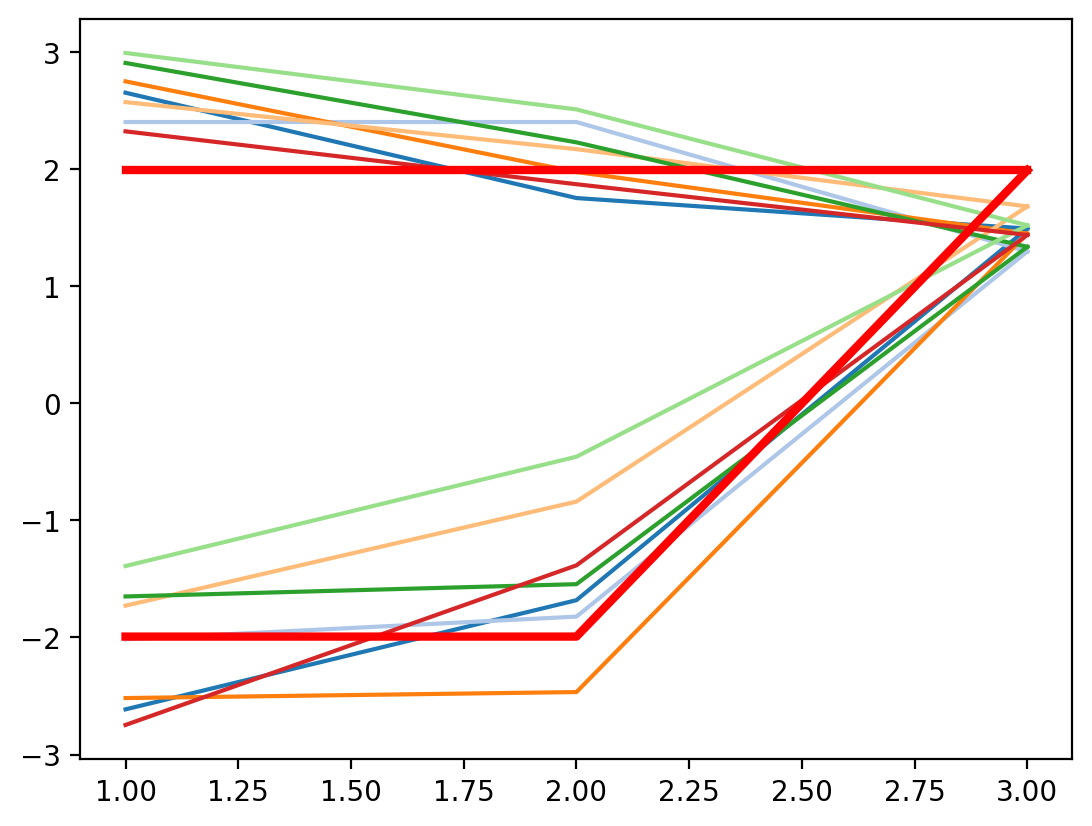

In [ ]:
_fig, _ax = plt.subplots()

for _i in range(separate_upper_lower_best.shape[0]):
    _ax.plot([1,2,3], separate_upper_lower_best.loc[_i, ["upper1", "upper2", "upper3"]], color = colors[_i])
    _ax.plot([1,2,3], separate_upper_lower_best.loc[_i, ["lower1", "lower2","upper3"]], color = colors[_i])

_ax.plot([1,2,3], [1.99218601, 1.99218601, 1.99218601], lw=3, color="red")
_ax.plot([1,2,3], [-1.99218601, -1.99218601, 1.99218601], lw=3, color="red")

_fig

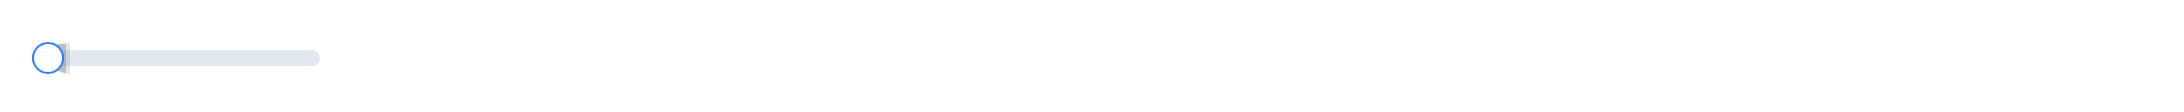

In [ ]:
slider3 = mo.ui.slider(start=0, stop=separate_upper_lower_best.shape[0]-1, step=1)
slider3

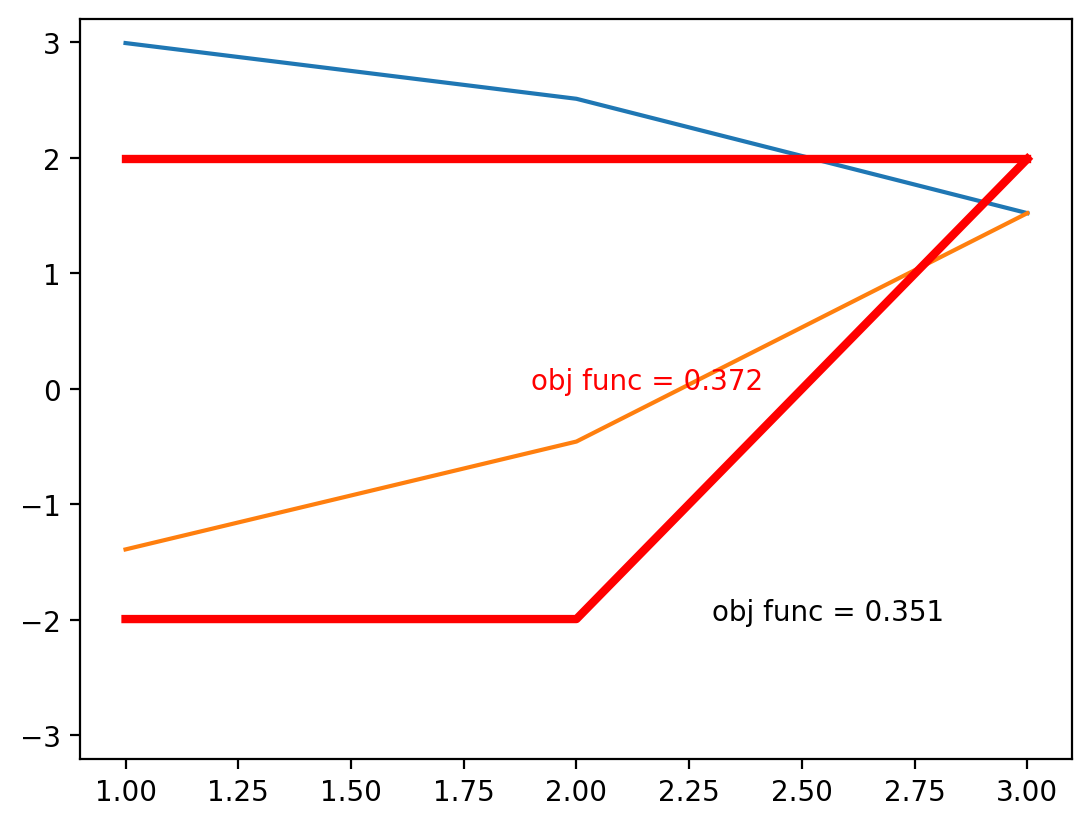

In [ ]:
plt.plot([1,2,3], separate_upper_lower_best.loc[slider3.value, ["upper1", "upper2", "upper3"]])
plt.plot([1,2,3], separate_upper_lower_best.loc[slider3.value, ["lower1", "lower2","upper3"]])

plt.plot([1,2,3], [1.99218601, 1.99218601, 1.99218601], lw=3, color="red")
plt.plot([1,2,3], [-1.99218601, -1.99218601, 1.99218601], lw=3, color="red")
plt.text(1.9, 0, str("obj func = ")+str(0.372), color = "red")

plt.text(2.3, -2, str("obj func = ")+str(separate_upper_lower_best.loc[slider3.value, "obj_f"].round(3)))

plt.ylim(-3.2, 3.2)

plt.show()

# Triangular region with monotonicity

## Bayesian optimization settings

- Penalty modified to include $\mathcal{L}=25$ if not monotonic, else same as above.
- GPR kernel was Matern52
- Lower bound of search space was `[1.85737722,  1.61125925,  1.57340768, -0.26220026,  0.86187545, 10]`
- Upper bound of search space was `[2.38177774, 2.13565977, 2.0978082,  0.26220026, 1.38627597, 30]`
- `acquisition_rule = EfficientGlobalOptimization`

## Import the data

In [ ]:
triang_mono = pd.read_csv(
    filepath_or_buffer="/tf/2026-03-t15/data/triang_monotonicity.csv",
    header=0,
    names=["upper1","upper2","upper3","lower1","lower2","n", "obj_f"]
)

## Check for monotonicity

In [ ]:
_monotonic = []

for _i in range(triang_mono.shape[0]):
    _bounds = triang_mono.loc[_i, ["upper1","upper2","upper3","lower1","lower2","n"]]
    _bounds_arr = np.array(_bounds)
    _monotonic.append(fmt_bd.check_monotonicity(n_analyses = 3, bounds = _bounds_arr))

triang_mono["monotonic"] = _monotonic

## Analyze the monotonic bounds

In [ ]:
triang_mono_remove_known = triang_mono.iloc[3:]

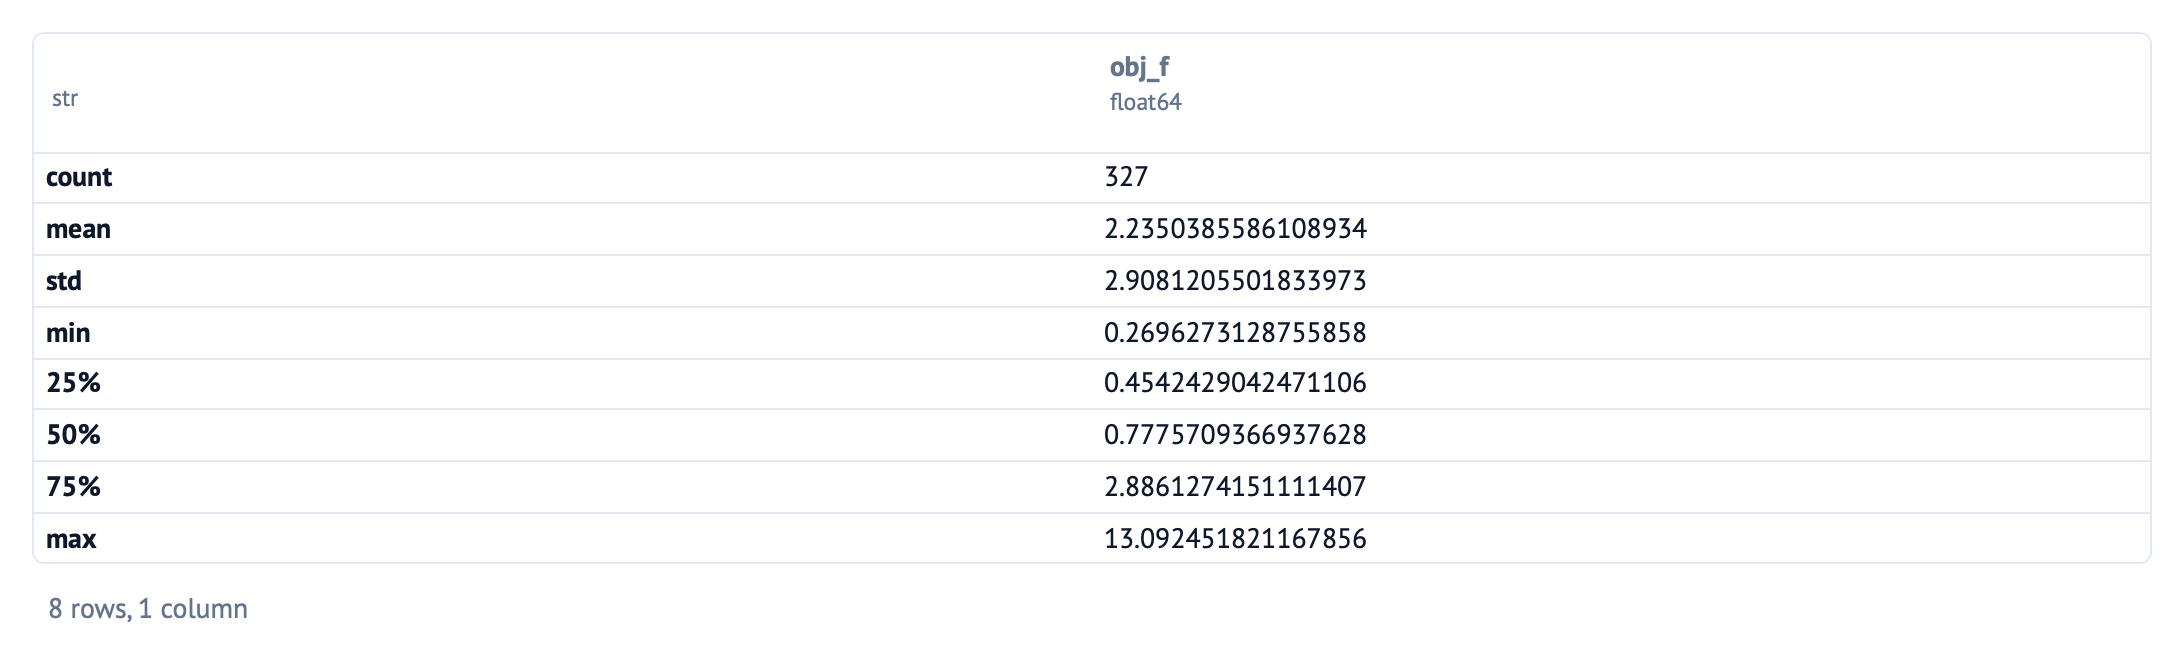

In [ ]:
triang_mono_remove_known[triang_mono_remove_known["monotonic"] == True]["obj_f"].describe()

### Of 700 runs, 327 monotonic, minimum penalty 0.2696 - 13.1

In [ ]:
mo.md(f"""
### {np.round(327/700*100, decimals=2)}%
""")

<span class="markdown prose dark:prose-invert contents"><h3 id="4671">46.71%</h3></span>

In [ ]:
triang_mono_best = triang_mono_remove_known[
    (triang_mono_remove_known["monotonic"] == True) & (triang_mono_remove_known["obj_f"] < 0.28)
].reset_index()

In [ ]:
triang_mono_best.shape

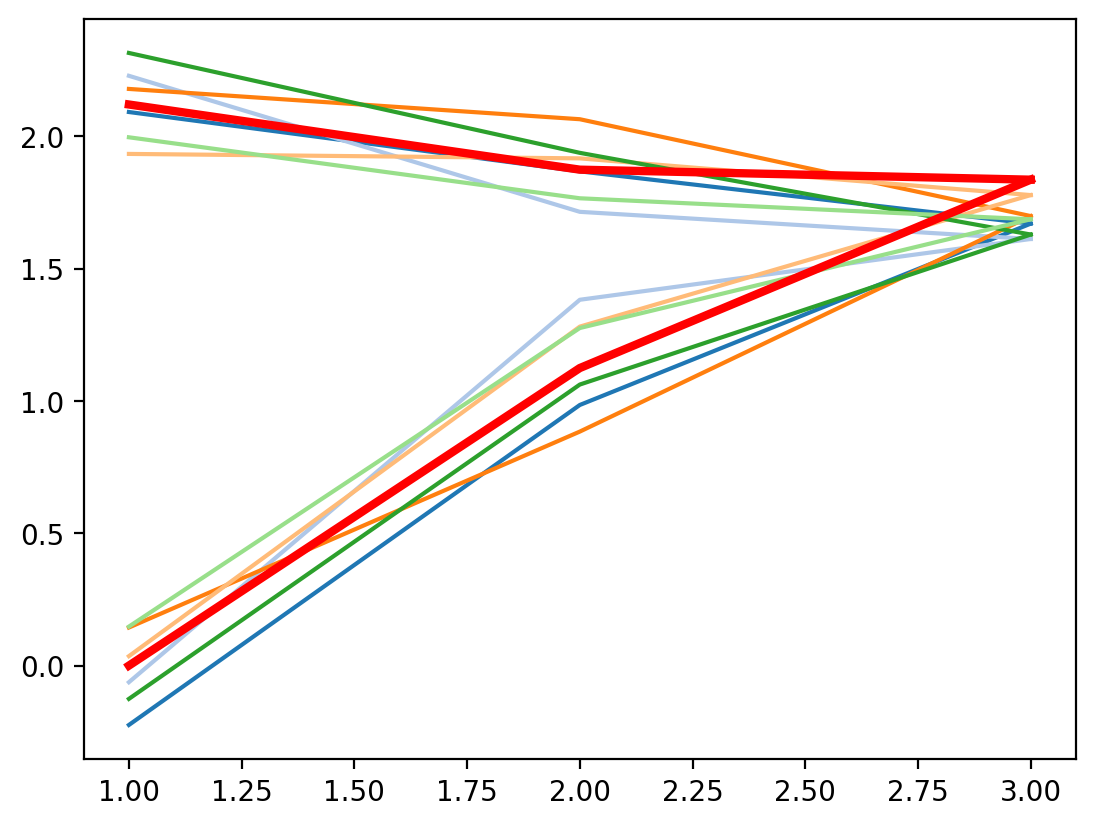

In [ ]:
_fig, _ax = plt.subplots()

for _i in range(triang_mono_best.shape[0]):
    _ax.plot([1,2,3], triang_mono_best.loc[_i, ["upper1", "upper2", "upper3"]], color = colors[_i])
    _ax.plot([1,2,3], triang_mono_best.loc[_i, ["lower1", "lower2","upper3"]], color = colors[_i])

_ax.plot([1,2,3], [2.119577478632703, 1.873459510489336, 1.8356079417852893], lw=3, color="red")
_ax.plot([1,2,3], [0.0000000000000006285533994301576, 1.1240757062936024, 1.8356079417852893], lw=3, color="red")

_fig

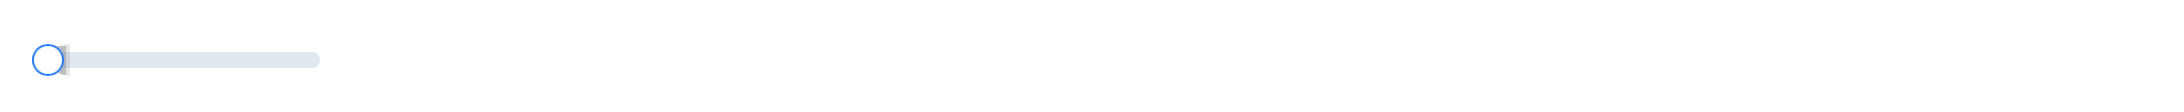

In [ ]:
slider4 = mo.ui.slider(start=0, stop=triang_mono_best.shape[0]-1, step=1)
slider4

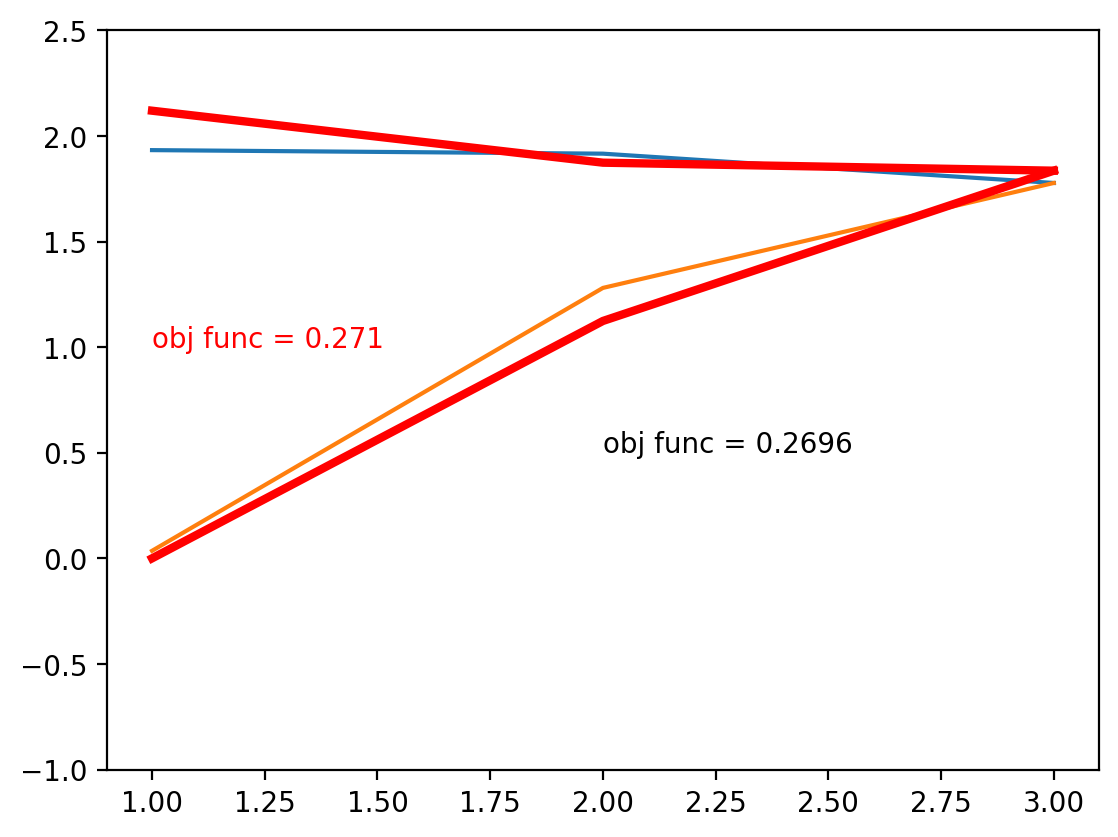

In [ ]:
plt.plot([1,2,3], triang_mono_best.loc[slider4.value, ["upper1", "upper2", "upper3"]])
plt.plot([1,2,3], triang_mono_best.loc[slider4.value, ["lower1", "lower2","upper3"]])

plt.plot([1,2,3], [2.119577478632703, 1.873459510489336, 1.8356079417852893], lw=3, color="red")
plt.plot([1,2,3], [0.0000000000000006285533994301576, 1.1240757062936024, 1.8356079417852893], lw=3, color="red")
plt.text(1, 1, str("obj func = 0.271"), color = "red")

plt.text(2, 0.5, str("obj func = ")+str(triang_mono_best.loc[slider4.value, "obj_f"].round(4)))

plt.ylim(-1, 2.5)

plt.show()

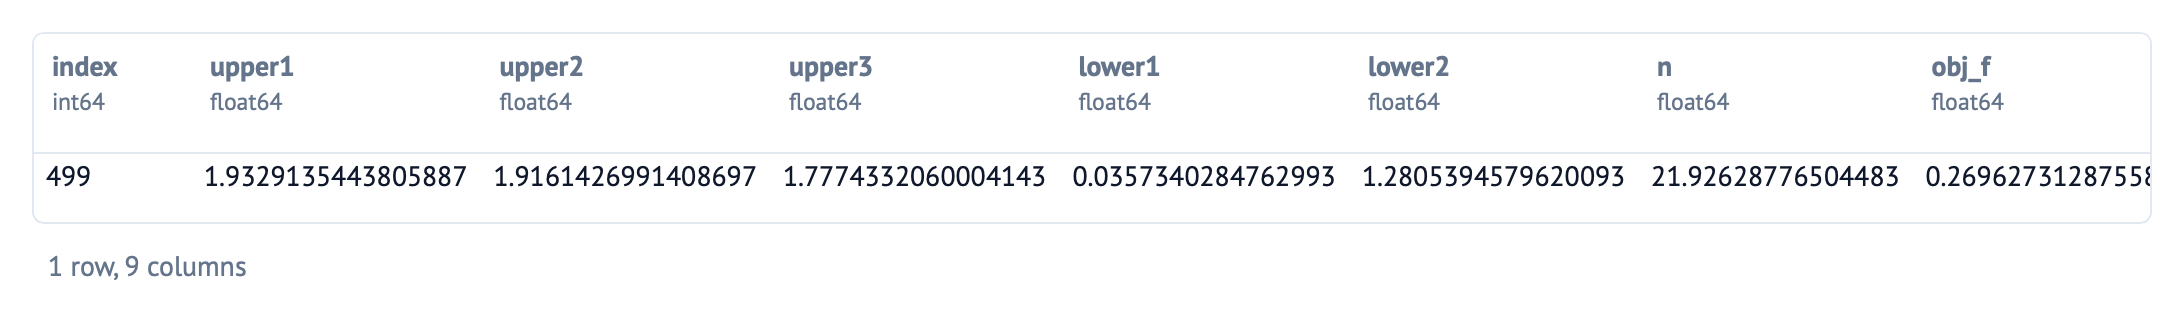

In [ ]:
triang_mono_best[triang_mono_best["obj_f"] < 0.27]

In [ ]:
sim.group_sequential_designs(
    n_analyses=3,
    upper_bounds=[1.9329135443805887, 1.9161426991408697, 1.7774332060004143],
    lower_bounds=[0.0357340284762993, 1.2805394579620093, 1.7774332060004143],
    n_patients=21.92628776504483,
    null_hypothesis=0,
    alt_hypothesis=1,
    variance=3
)

# Triangular region without monotonicity

## Bayesian optimization settings

- GPR kernel was Matern52
- Lower bound of search space was `[1.85737722,  1.61125925,  1.57340768, -0.26220026,  0.86187545, 10]`
- Upper bound of search space was `[2.38177774, 2.13565977, 2.0978082,  0.26220026, 1.38627597, 30]`
- `acquisition_rule = EfficientGlobalOptimization`

## Import the data

In [ ]:
triang_no_mono = pd.read_csv(
    filepath_or_buffer="/tf/2026-03-t15/data/triang_no_monotonicity.csv",
    header=0,
    names=["upper1","upper2","upper3","lower1","lower2","n", "obj_f"]
)

## Check for monotonicity

In [ ]:
_monotonic = []

for _i in range(triang_no_mono.shape[0]):
    _bounds = triang_no_mono.loc[_i, ["upper1","upper2","upper3","lower1","lower2","n"]]
    _bounds_arr = np.array(_bounds)
    _monotonic.append(fmt_bd.check_monotonicity(n_analyses = 3, bounds = _bounds_arr))

triang_no_mono["monotonic"] = _monotonic

## Analyze the monotonic bounds

In [ ]:
triang_no_mono_remove_known = triang_no_mono.iloc[3:]

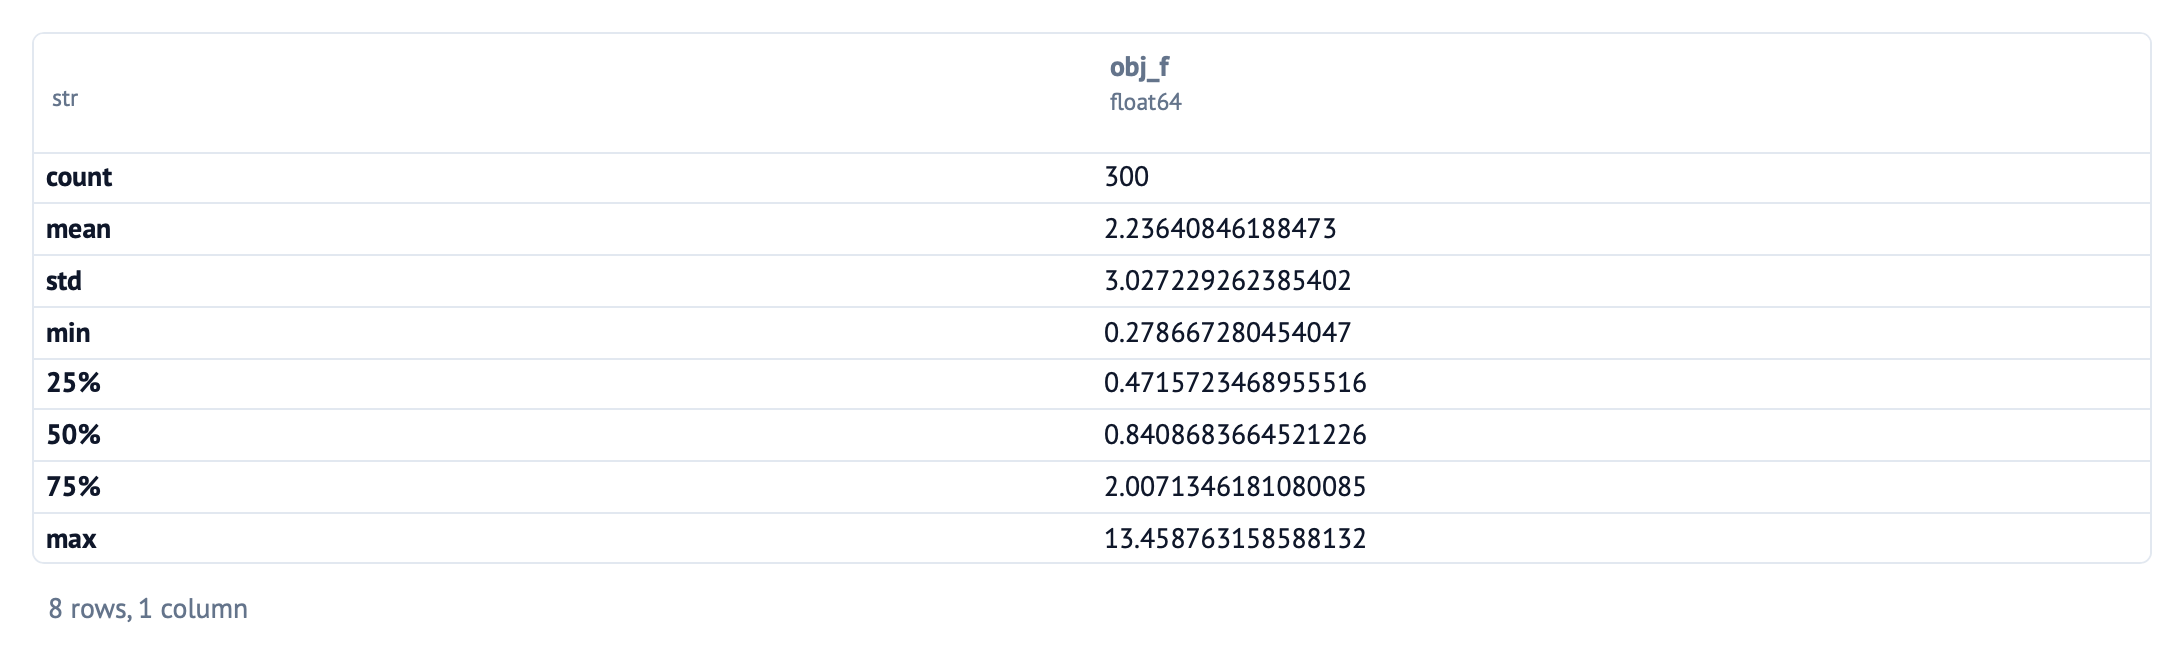

In [ ]:
triang_no_mono_remove_known[triang_no_mono_remove_known["monotonic"] == True]["obj_f"].describe()

### Of 700 runs, 300 monotonic, minimum penalty 0.2786 - 13.5

In [ ]:
mo.md(rf"""
### {np.round(300/700*100, decimals=2)}%
""")

<span class="markdown prose dark:prose-invert contents"><h3 id="4286">42.86%</h3></span>

In [ ]:
triang_no_mono_best = triang_no_mono_remove_known[
    (triang_no_mono_remove_known["monotonic"] == True) & (triang_no_mono_remove_known["obj_f"] < 0.29)
].reset_index()

In [ ]:
triang_no_mono_best.shape

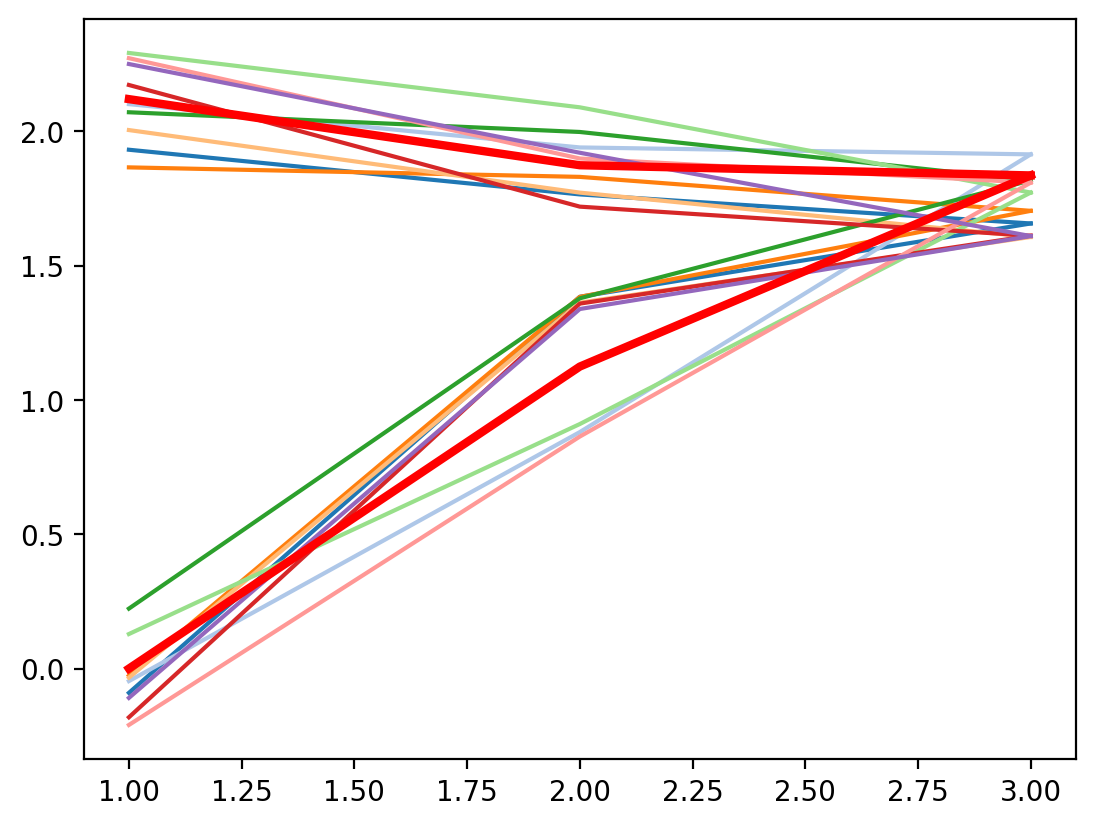

In [ ]:
_fig, _ax = plt.subplots()

for _i in range(triang_no_mono_best.shape[0]):
    _ax.plot([1,2,3], triang_no_mono_best.loc[_i, ["upper1", "upper2", "upper3"]], color = colors[_i])
    _ax.plot([1,2,3], triang_no_mono_best.loc[_i, ["lower1", "lower2","upper3"]], color = colors[_i])

_ax.plot([1,2,3], [2.119577478632703, 1.873459510489336, 1.8356079417852893], lw=3, color="red")
_ax.plot([1,2,3], [0.0000000000000006285533994301576, 1.1240757062936024, 1.8356079417852893], lw=3, color="red")

_fig

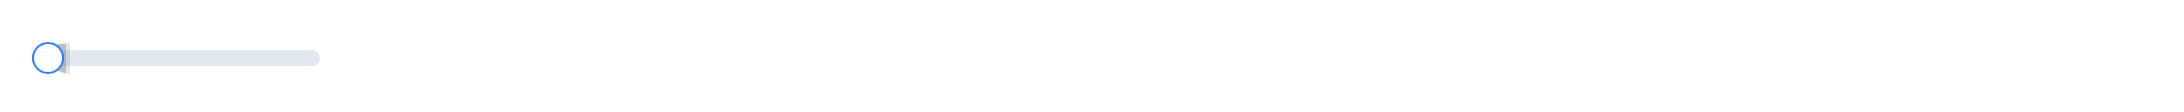

In [ ]:
slider5 = mo.ui.slider(start=0, stop=triang_no_mono_best.shape[0]-1, step=1)
slider5

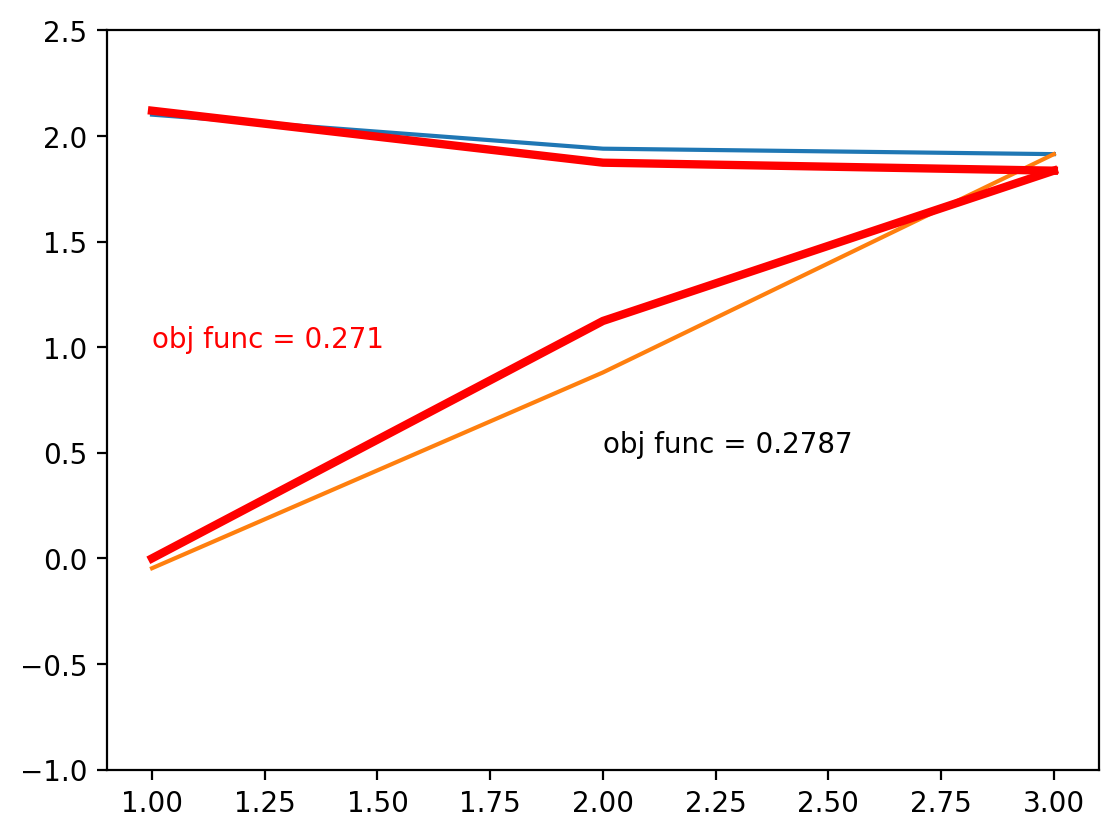

In [ ]:
plt.plot([1,2,3], triang_no_mono_best.loc[slider5.value, ["upper1", "upper2", "upper3"]])
plt.plot([1,2,3], triang_no_mono_best.loc[slider5.value, ["lower1", "lower2","upper3"]])

plt.plot([1,2,3], [2.119577478632703, 1.873459510489336, 1.8356079417852893], lw=3, color="red")
plt.plot([1,2,3], [0.0000000000000006285533994301576, 1.1240757062936024, 1.8356079417852893], lw=3, color="red")
plt.text(1, 1, str("obj func = 0.271"), color = "red")

plt.text(2, 0.5, str("obj func = ")+str(triang_no_mono_best.loc[slider5.value, "obj_f"].round(4)))

plt.ylim(-1, 2.5)

plt.show()

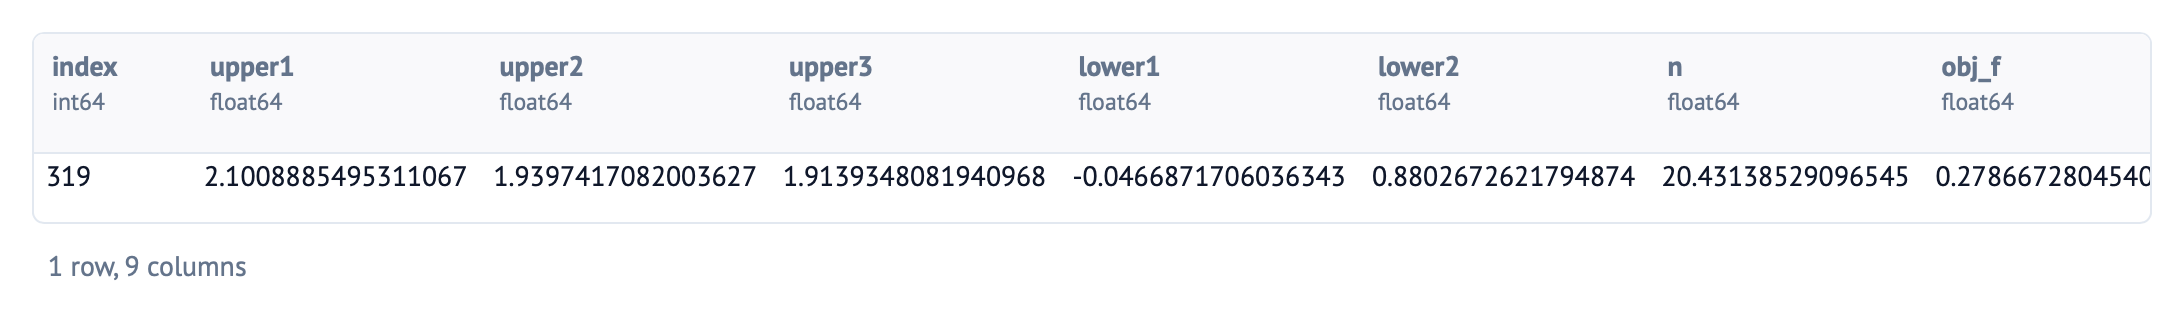

In [ ]:
triang_no_mono_best[triang_no_mono_best["obj_f"] < 0.2789]

In [ ]:
sim.group_sequential_designs(
    n_analyses=3,
    upper_bounds=[2.1008885495311067, 1.9397417082003627, 1.9139348081940968],
    lower_bounds=[-0.0466871706036343, 0.8802672621794874, 1.9139348081940968],
    n_patients=20.43138529096545,
    null_hypothesis=0,
    alt_hypothesis=1,
    variance=3
)

# Failure region Bayes opt

## Bayesian optimization settings

- GPR kernel was Matern52, Gaussian likelihood
- VGP kernel was squared exponential, Bernoulli likelihood
- Aquisition function was a product of expected improvement for GPR and probability of validity for the VGP
- `acquisition_rule = EfficientGlobalOptimization`
- Lower bound of search space `[-3,-3,-3,-3,-3, 10]`
- Upper bound of search space `[ 3, 3, 3, 3, 3, 30]`

## Run 1

In [ ]:
run1 = pd.read_csv(filepath_or_buffer="/tf/2026-03-t16/failure_bounds_run1.csv")
run1.shape

In [ ]:
np.sum(run1["output"])

20.0

In [ ]:
bounds_run1 = pd.read_csv(filepath_or_buffer="/tf/2026-03-t16/failure_region_bounds_run1.csv")
bounds_run1.rename(columns={"penalty" : "obj_f"}, inplace=True)

In [ ]:
bounds_run1_remove_known = bounds_run1.iloc[3:]

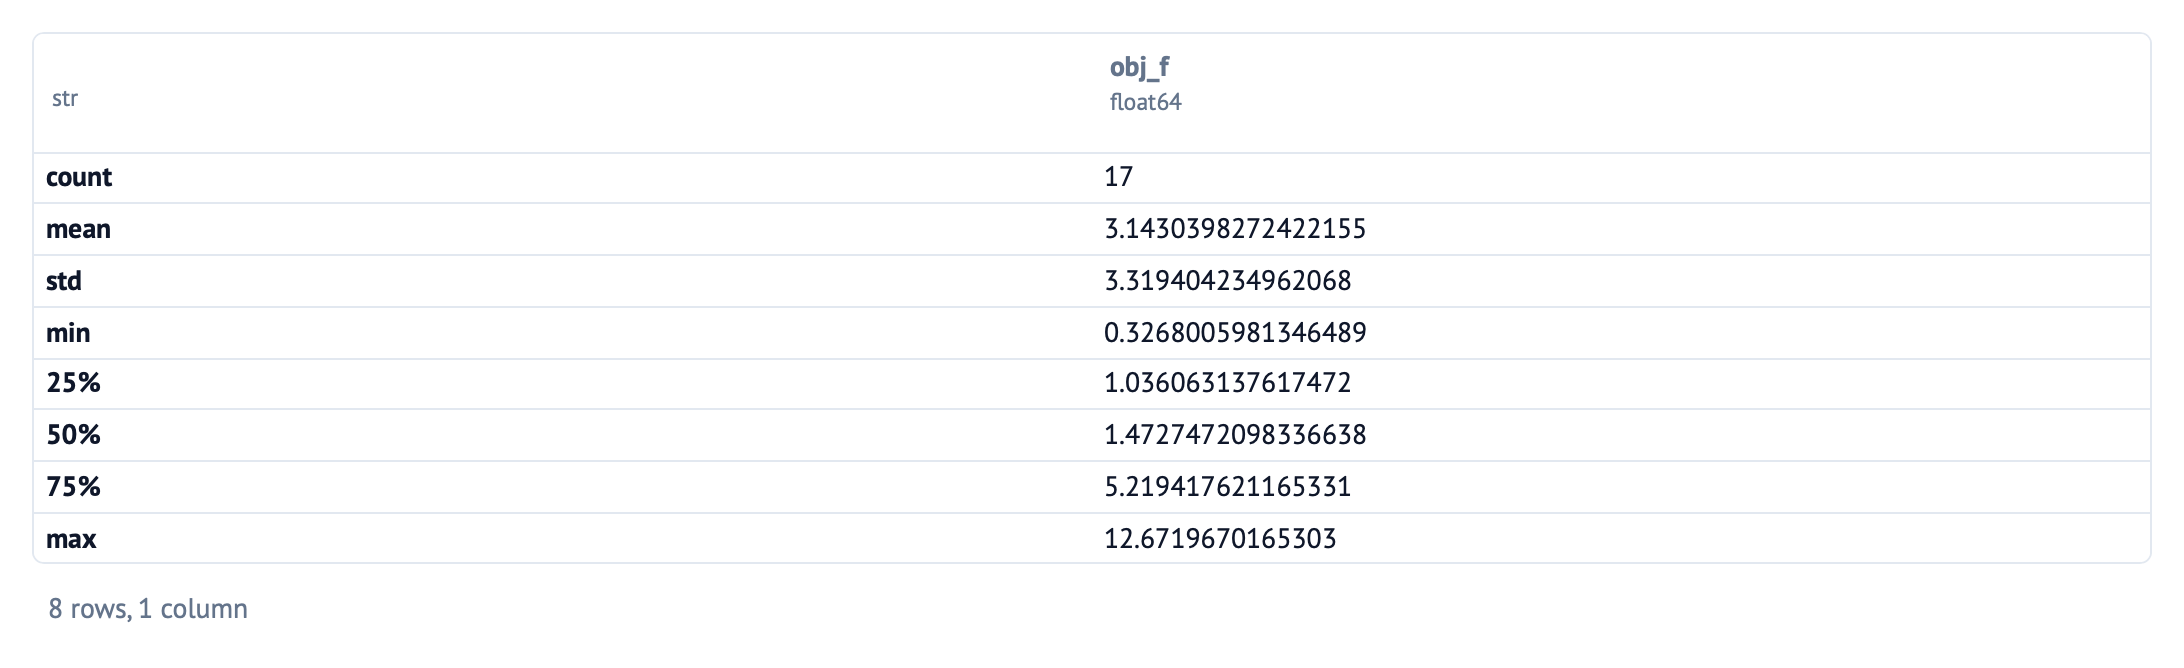

In [ ]:
bounds_run1_remove_known["obj_f"].describe()

### Of 437 runs, 17 monotonic, minimum penalty 0.3268 - 12.67

In [ ]:
mo.md(rf"""
### {np.round(17/437*100, decimals=2)}%
""")

<span class="markdown prose dark:prose-invert contents"><h3 id="389">3.89%</h3></span>

In [ ]:
bounds_run1_best = bounds_run1_remove_known[bounds_run1_remove_known["obj_f"] < 1].reset_index()

In [ ]:
bounds_run1_best.shape

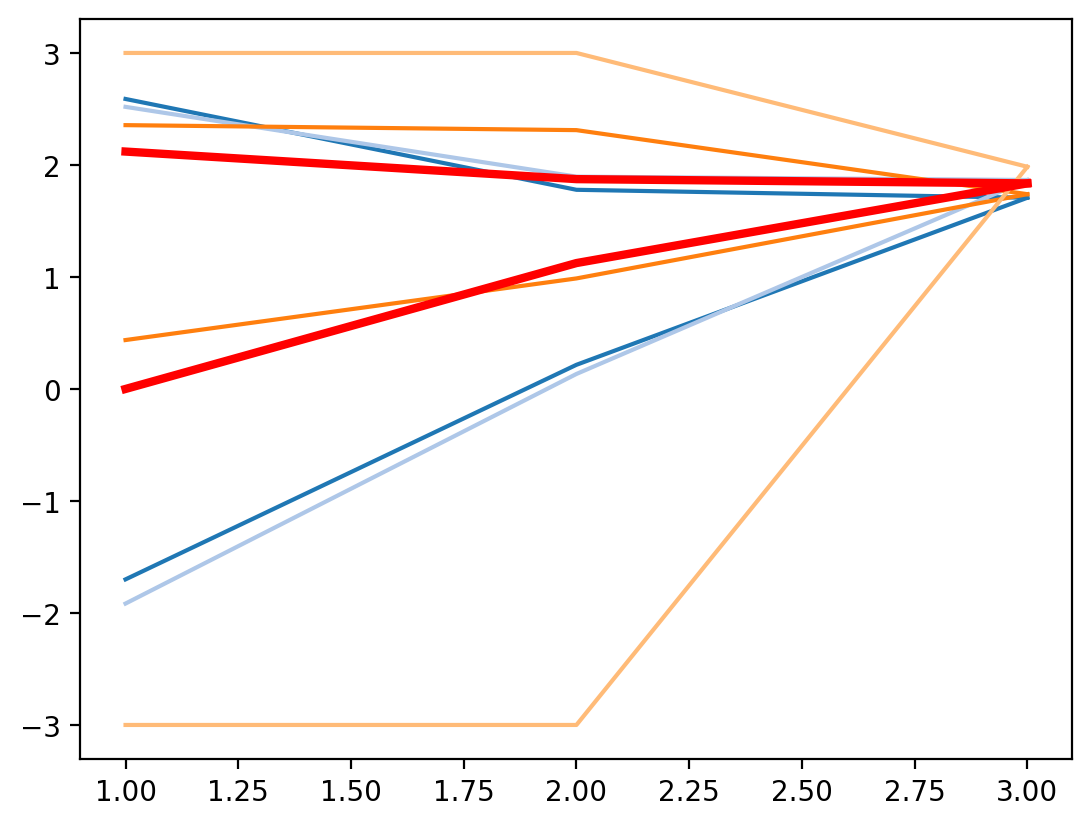

In [ ]:
_fig, _ax = plt.subplots()

for _i in range(bounds_run1_best.shape[0]):
    _ax.plot([1,2,3], bounds_run1_best.loc[_i, ["upper1", "upper2", "upper3"]], color = colors[_i])
    _ax.plot([1,2,3], bounds_run1_best.loc[_i, ["lower1", "lower2","upper3"]], color = colors[_i])

_ax.plot([1,2,3], [2.119577478632703, 1.873459510489336, 1.8356079417852893], lw=3, color="red")
_ax.plot([1,2,3], [0.0000000000000006285533994301576, 1.1240757062936024, 1.8356079417852893], lw=3, color="red")

_fig

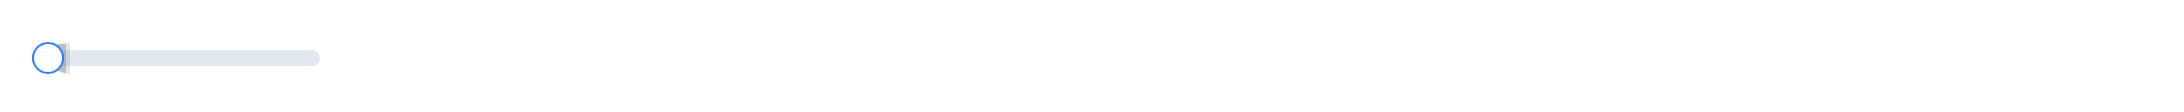

In [ ]:
slider6 = mo.ui.slider(start=0, stop=bounds_run1_best.shape[0]-1, step=1)
slider6

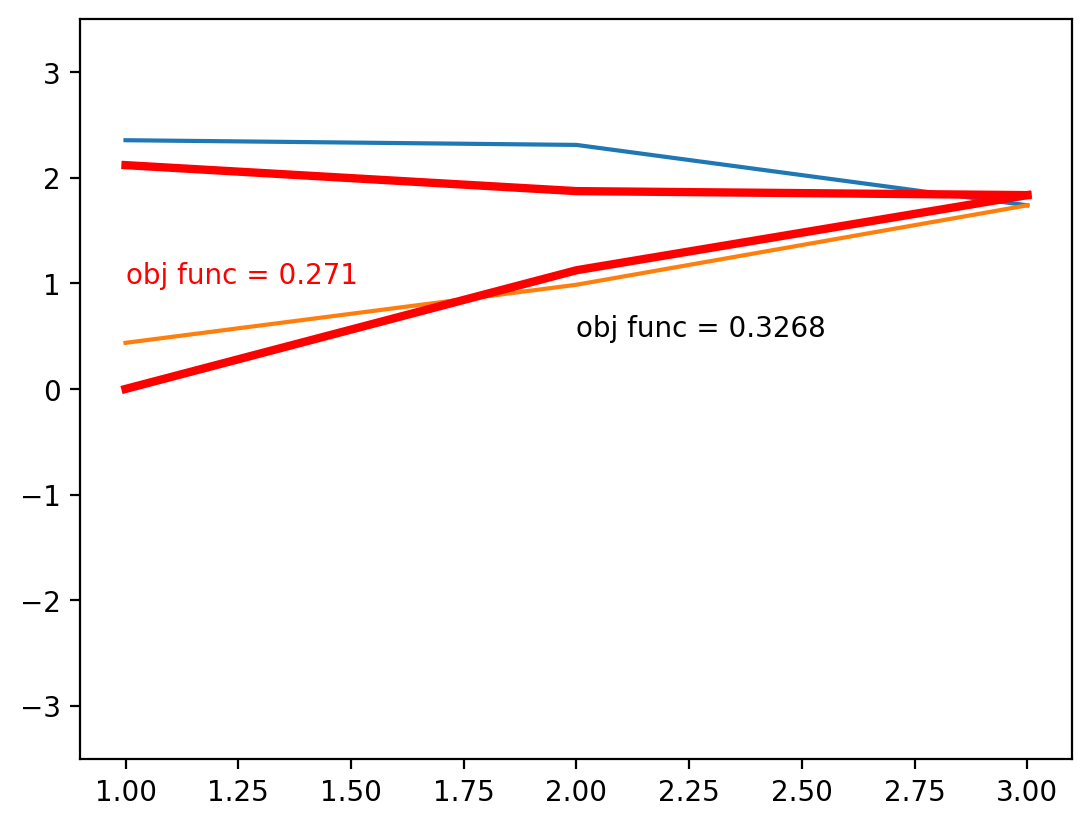

In [ ]:
plt.plot([1,2,3], bounds_run1_best.loc[slider6.value, ["upper1", "upper2", "upper3"]])
plt.plot([1,2,3], bounds_run1_best.loc[slider6.value, ["lower1", "lower2","upper3"]])

plt.plot([1,2,3], [2.119577478632703, 1.873459510489336, 1.8356079417852893], lw=3, color="red")
plt.plot([1,2,3], [0.0000000000000006285533994301576, 1.1240757062936024, 1.8356079417852893], lw=3, color="red")
plt.text(1, 1, str("obj func = 0.271"), color = "red")

plt.text(2, 0.5, str("obj func = ")+str(bounds_run1_best.loc[slider6.value, "obj_f"].round(4)))

plt.ylim(-3.5, 3.5)

plt.show()

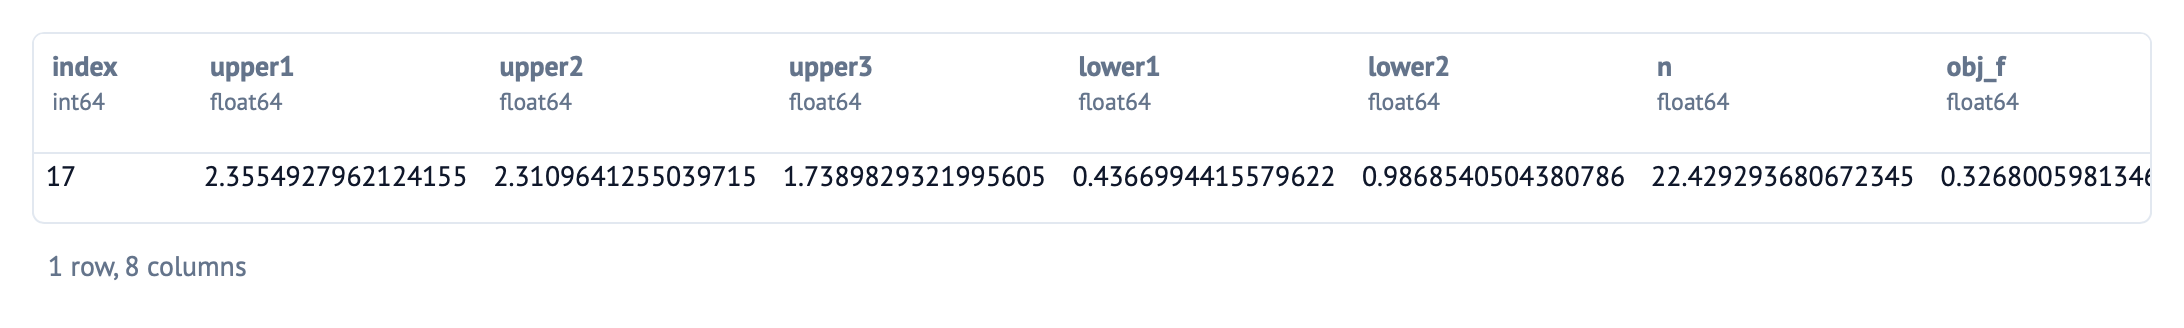

In [ ]:
bounds_run1_best[bounds_run1_best["obj_f"] < 0.33]

In [ ]:
sim.group_sequential_designs(
    n_analyses=3,
    upper_bounds=[2.3554927962124155, 2.3109641255039715, 1.7389829321995605],
    lower_bounds=[0.4366994415579622, 0.9868540504380786, 1.7389829321995605],
    n_patients=22.429293680672345,
    null_hypothesis=0,
    alt_hypothesis=1,
    variance=3
)

## Run 2

In [ ]:
run2 = pd.read_csv(filepath_or_buffer="/tf/2026-03-t16/failure_bounds_run2.csv")
run2.shape

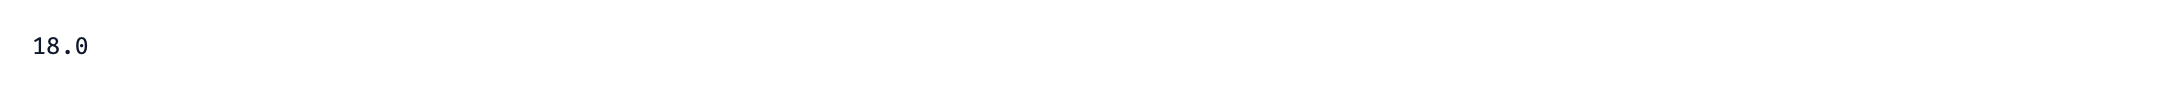

In [ ]:
np.sum(run2["output"])

In [ ]:
bounds_run2 = pd.read_csv(filepath_or_buffer="/tf/2026-03-t16/failure_region_bounds_run2.csv")
bounds_run2.rename(columns={"penalty" : "obj_f"}, inplace=True)

In [ ]:
bounds_run2_remove_known = bounds_run2.iloc[3:]

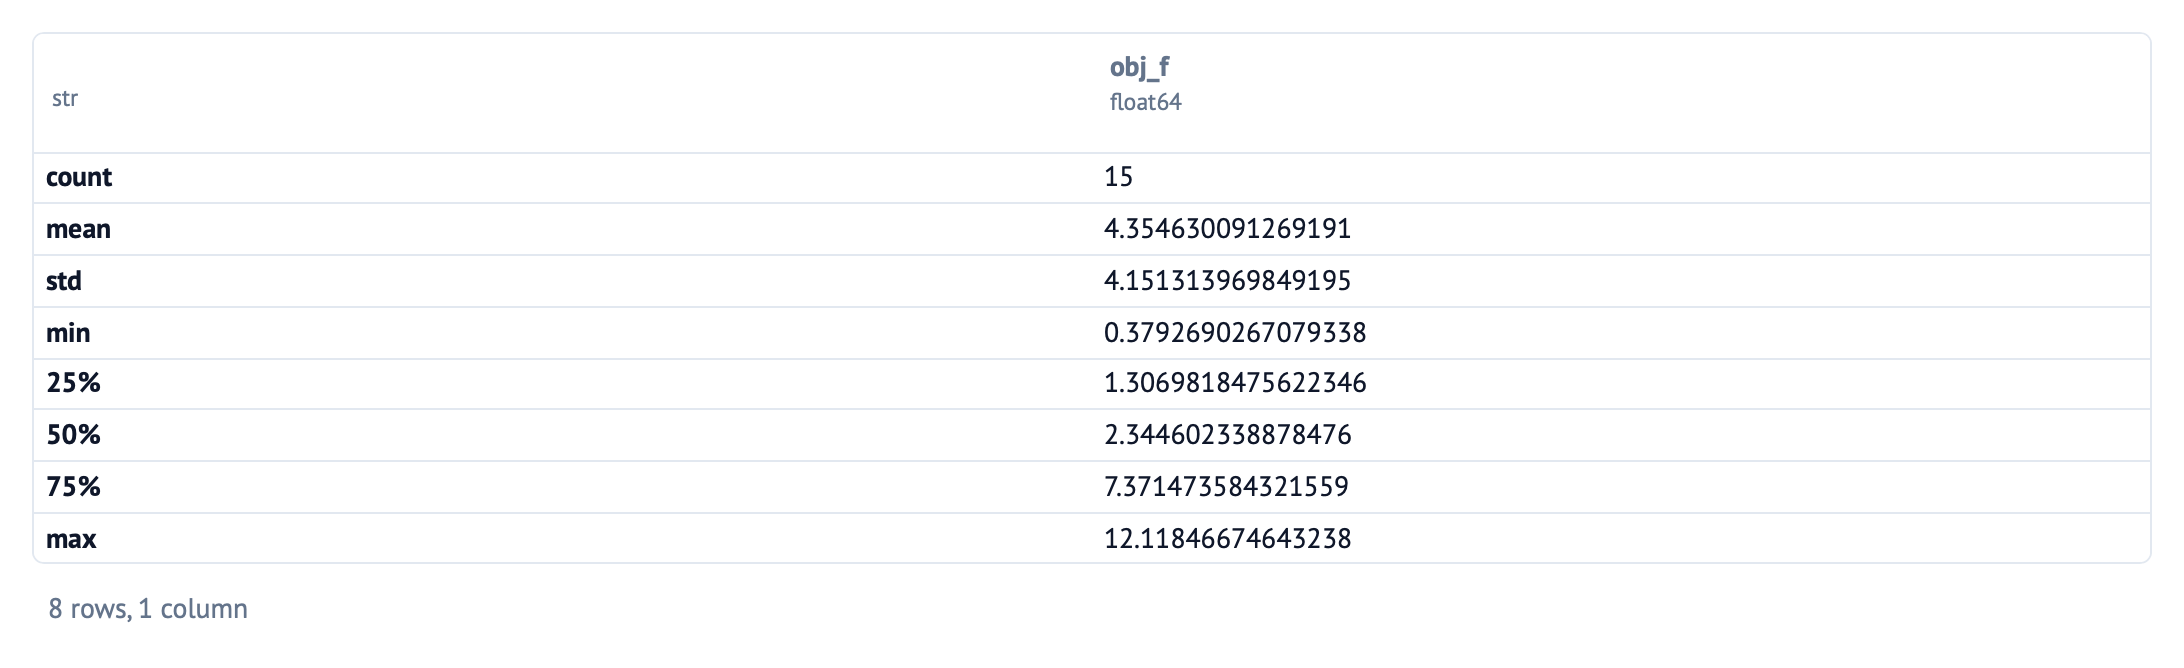

In [ ]:
bounds_run2_remove_known["obj_f"].describe()

### Of 460 runs, 15 monotonic, minimum penalty 0.379 - 12.11

In [ ]:
mo.md(rf"""
### {np.round(15/460*100, decimals=2)}%
""")

<span class="markdown prose dark:prose-invert contents"><h3 id="326">3.26%</h3></span>

In [ ]:
bounds_run2_best = bounds_run2_remove_known[bounds_run2_remove_known["obj_f"] < 1].reset_index()

In [ ]:
bounds_run2_best.shape

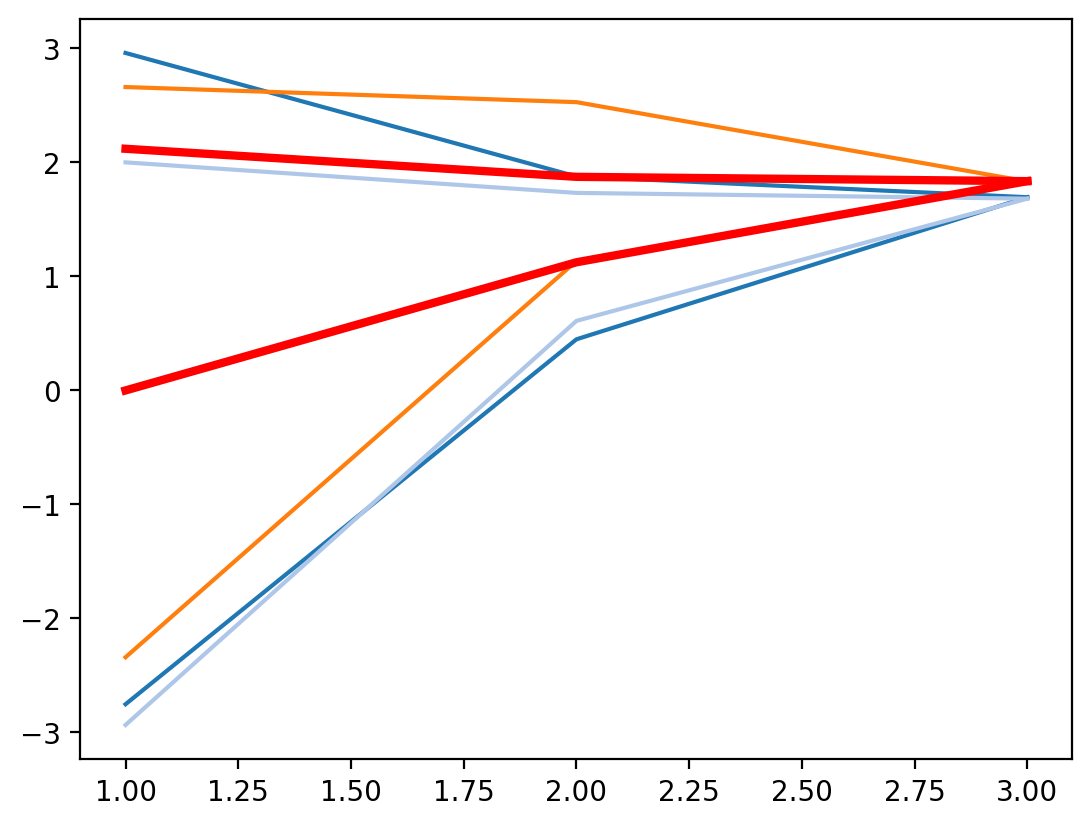

In [ ]:
_fig, _ax = plt.subplots()

for _i in range(bounds_run2_best.shape[0]):
    _ax.plot([1,2,3], bounds_run2_best.loc[_i, ["upper1", "upper2", "upper3"]], color = colors[_i])
    _ax.plot([1,2,3], bounds_run2_best.loc[_i, ["lower1", "lower2","upper3"]], color = colors[_i])

_ax.plot([1,2,3], [2.119577478632703, 1.873459510489336, 1.8356079417852893], lw=3, color="red")
_ax.plot([1,2,3], [0.0000000000000006285533994301576, 1.1240757062936024, 1.8356079417852893], lw=3, color="red")

_fig

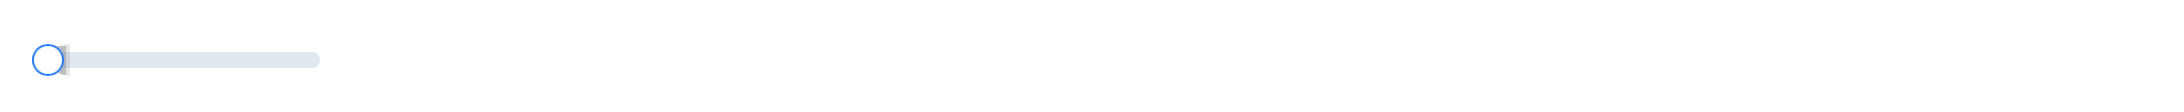

In [ ]:
slider7 = mo.ui.slider(start=0, stop=bounds_run2_best.shape[0]-1, step=1)
slider7

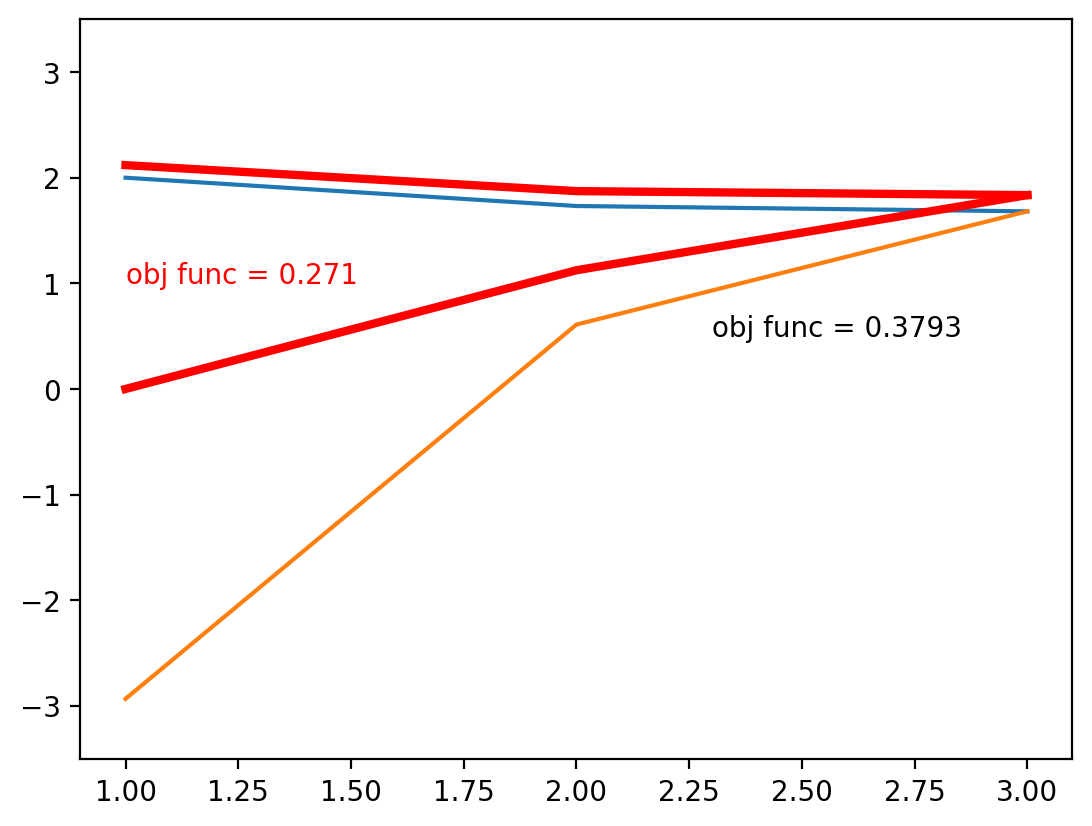

In [ ]:
plt.plot([1,2,3], bounds_run2_best.loc[slider7.value, ["upper1", "upper2", "upper3"]])
plt.plot([1,2,3], bounds_run2_best.loc[slider7.value, ["lower1", "lower2","upper3"]])

plt.plot([1,2,3], [2.119577478632703, 1.873459510489336, 1.8356079417852893], lw=3, color="red")
plt.plot([1,2,3], [0.0000000000000006285533994301576, 1.1240757062936024, 1.8356079417852893], lw=3, color="red")
plt.text(1, 1, str("obj func = 0.271"), color = "red")

plt.text(2.3, 0.5, str("obj func = ")+str(bounds_run2_best.loc[slider7.value, "obj_f"].round(4)))

plt.ylim(-3.5, 3.5)

plt.show()

## Run 3

In [ ]:
run3 = pd.read_csv(filepath_or_buffer="/tf/2026-03-t16/failure_bounds_run3.csv")
run3.shape

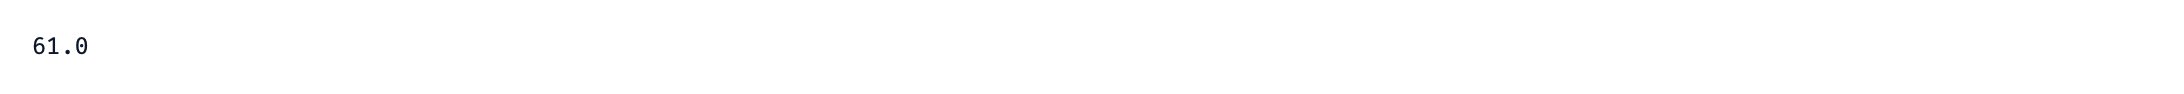

In [ ]:
np.sum(run3["output"])

In [ ]:
bounds_run3 = pd.read_csv(filepath_or_buffer="/tf/2026-03-t16/failure_region_bounds_run3.csv")
bounds_run3.rename(columns={"penalty" : "obj_f"}, inplace=True)

In [ ]:
bounds_run3_remove_known = bounds_run3.iloc[3:]

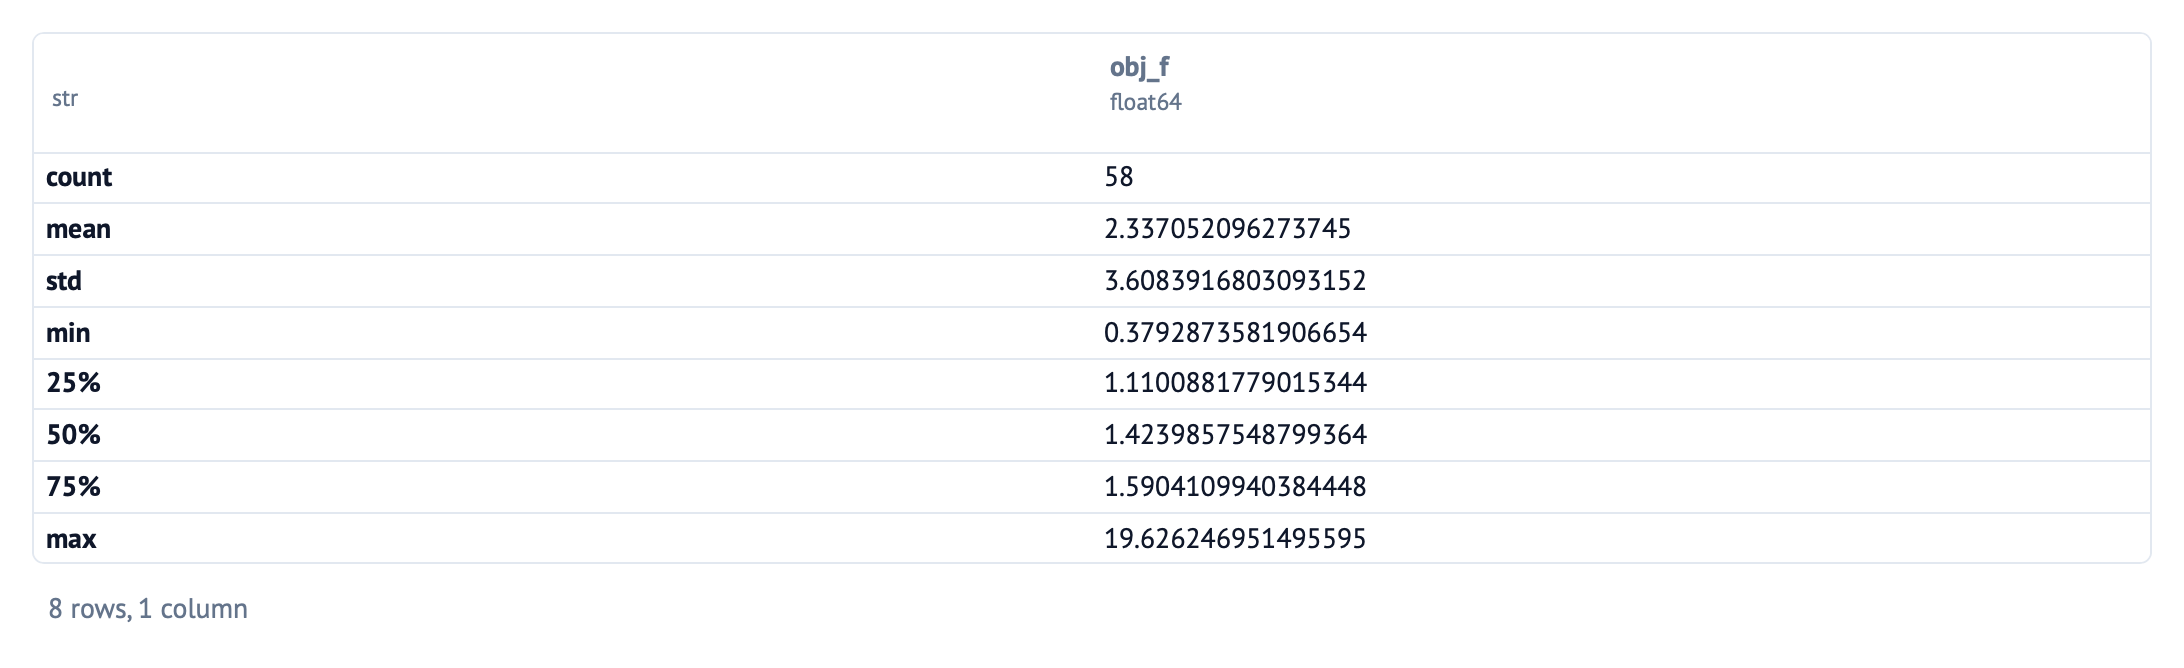

In [ ]:
bounds_run3_remove_known["obj_f"].describe()

### Of 889 runs, 58 monotonic, minimum penalty 0.379 - 19.6

In [ ]:
mo.md(rf"""
### {np.round(58/889*100, decimals=2)}%
""")

<span class="markdown prose dark:prose-invert contents"><h3 id="652">6.52%</h3></span>

In [ ]:
bounds_run3_best = bounds_run3_remove_known[bounds_run3_remove_known["obj_f"] < 0.5].reset_index()

In [ ]:
bounds_run3_best.shape

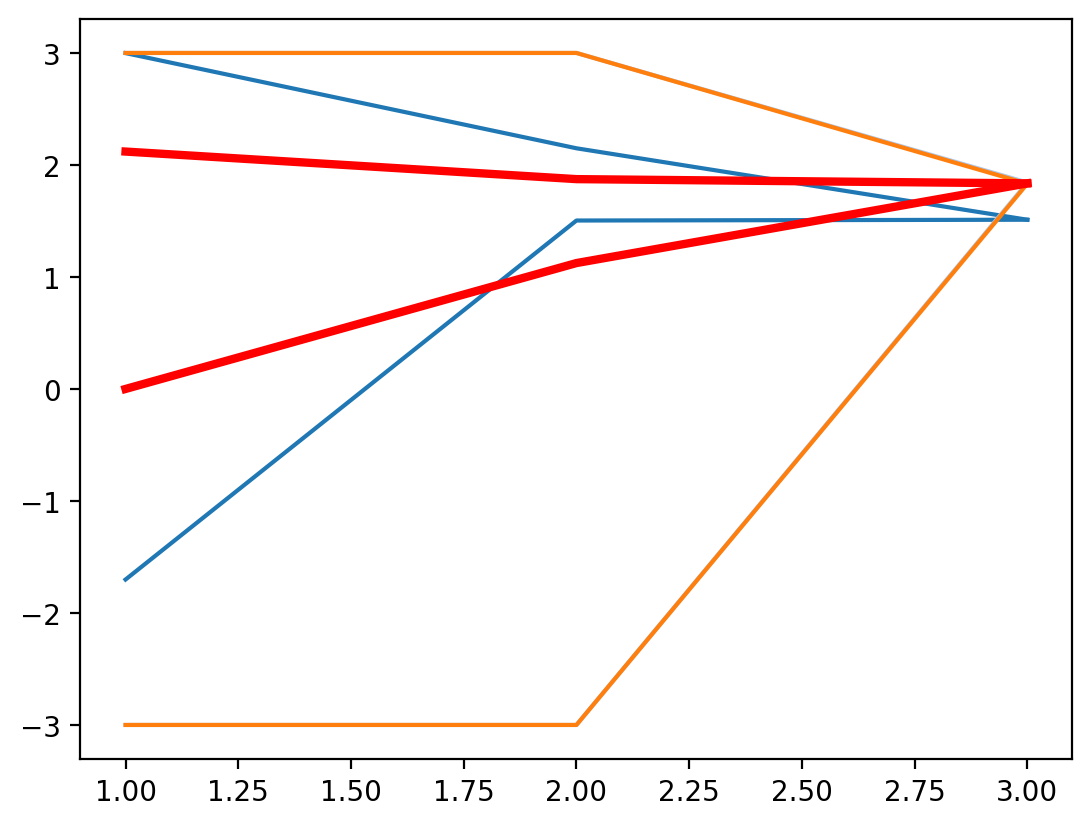

In [ ]:
_fig, _ax = plt.subplots()

for _i in range(bounds_run3_best.shape[0]):
    _ax.plot([1,2,3], bounds_run3_best.loc[_i, ["upper1", "upper2", "upper3"]], color = colors[_i])
    _ax.plot([1,2,3], bounds_run3_best.loc[_i, ["lower1", "lower2","upper3"]], color = colors[_i])

_ax.plot([1,2,3], [2.119577478632703, 1.873459510489336, 1.8356079417852893], lw=3, color="red")
_ax.plot([1,2,3], [0.0000000000000006285533994301576, 1.1240757062936024, 1.8356079417852893], lw=3, color="red")

_fig

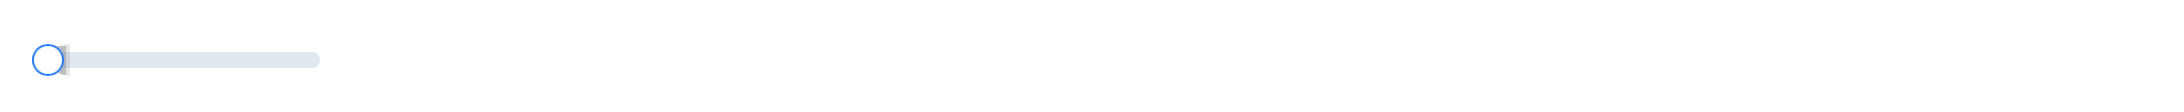

In [ ]:
slider8 = mo.ui.slider(start=0, stop=bounds_run3_best.shape[0]-1, step=1)
slider8

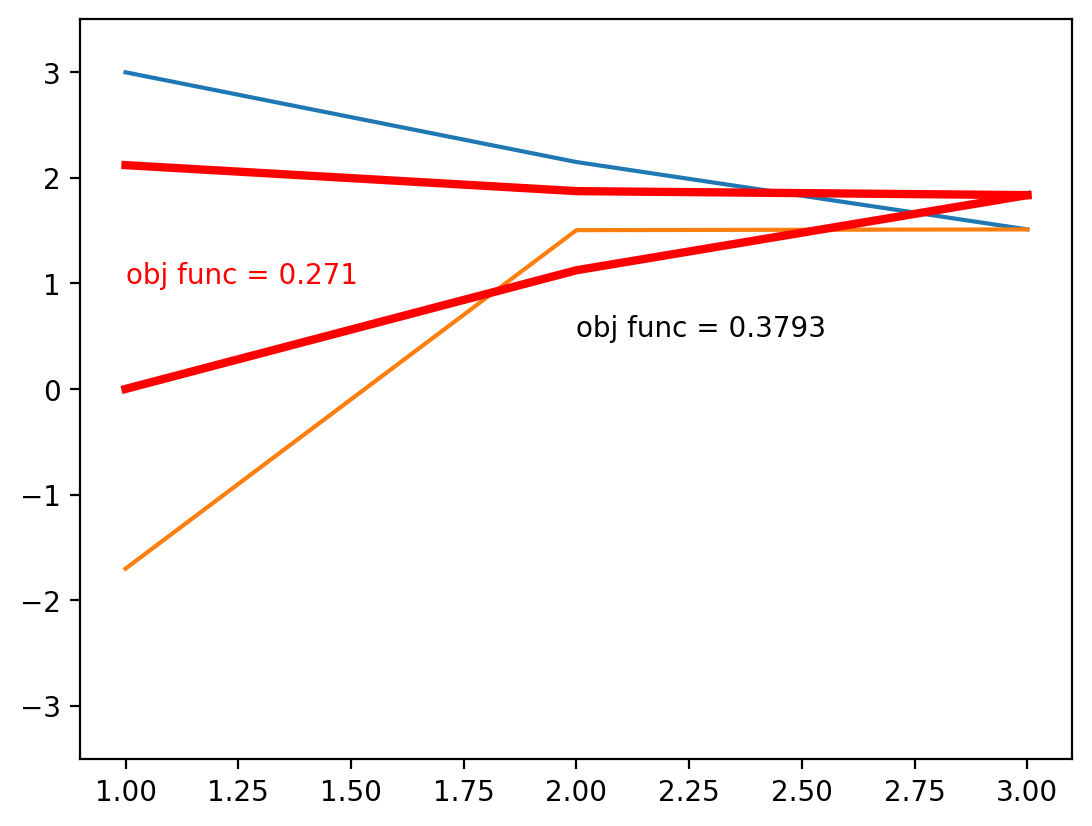

In [ ]:
plt.plot([1,2,3], bounds_run3_best.loc[slider8.value, ["upper1", "upper2", "upper3"]])
plt.plot([1,2,3], bounds_run3_best.loc[slider8.value, ["lower1", "lower2","upper3"]])

plt.plot([1,2,3], [2.119577478632703, 1.873459510489336, 1.8356079417852893], lw=3, color="red")
plt.plot([1,2,3], [0.0000000000000006285533994301576, 1.1240757062936024, 1.8356079417852893], lw=3, color="red")
plt.text(1, 1, str("obj func = 0.271"), color = "red")

plt.text(2, 0.5, str("obj func = ")+str(bounds_run3_best.loc[slider8.value, "obj_f"].round(4)))

plt.ylim(-3.5, 3.5)

plt.show()

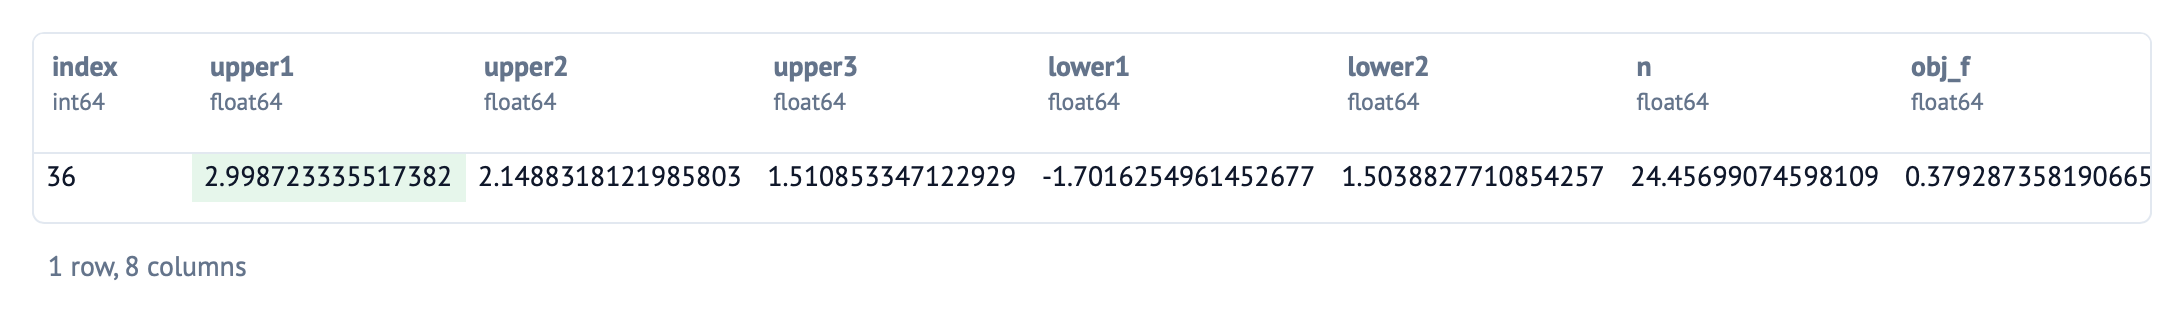

In [ ]:
bounds_run3_best[bounds_run3_best["obj_f"] < 0.38]

In [ ]:
sim.group_sequential_designs(
    n_analyses=3,
    upper_bounds=[2.998723335517382, 2.1488318121985803, 1.510853347122929],
    lower_bounds=[-1.7016254961452677, 1.5038827710854257, 1.510853347122929],
    n_patients=24.45699074598109,
    null_hypothesis=0,
    alt_hypothesis=1,
    variance=3
)

## Run 4

In [ ]:
run4 = pd.read_csv(filepath_or_buffer="/tf/2026-03-t16/failure_bounds_run4.csv")
run4.shape

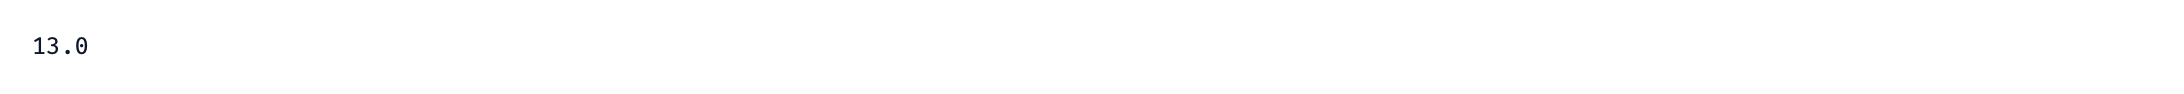

In [ ]:
np.sum(run4["output"])

In [ ]:
bounds_run4 = pd.read_csv(filepath_or_buffer="/tf/2026-03-t16/failure_region_bounds_run4.csv")
bounds_run4.rename(columns={"penalty" : "obj_f"}, inplace=True)

In [ ]:
bounds_run4_remove_known = bounds_run4.iloc[3:]

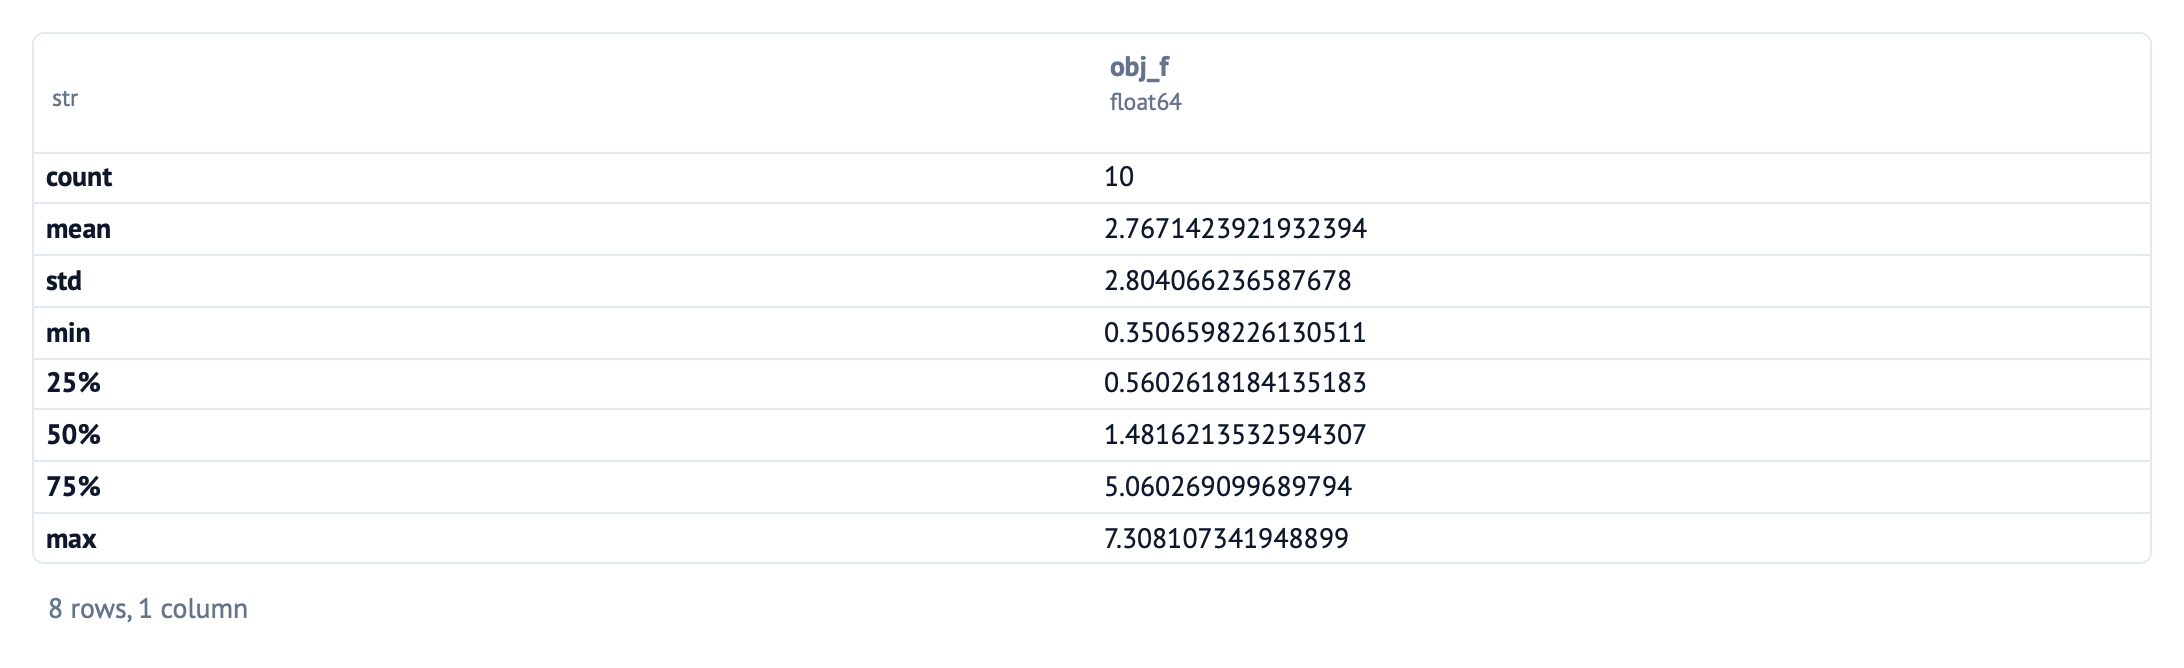

In [ ]:
bounds_run4_remove_known["obj_f"].describe()

### Of 448 runs, 10 monotonic, minimum penalty 0.351 - 7.31

In [ ]:
mo.md(rf"""
### {np.round(10/448*100, decimals=2)}%
""")

<span class="markdown prose dark:prose-invert contents"><h3 id="223">2.23%</h3></span>

In [ ]:
bounds_run4_best = bounds_run4_remove_known[bounds_run4_remove_known["obj_f"] < 0.5].reset_index()

In [ ]:
bounds_run4_best.shape

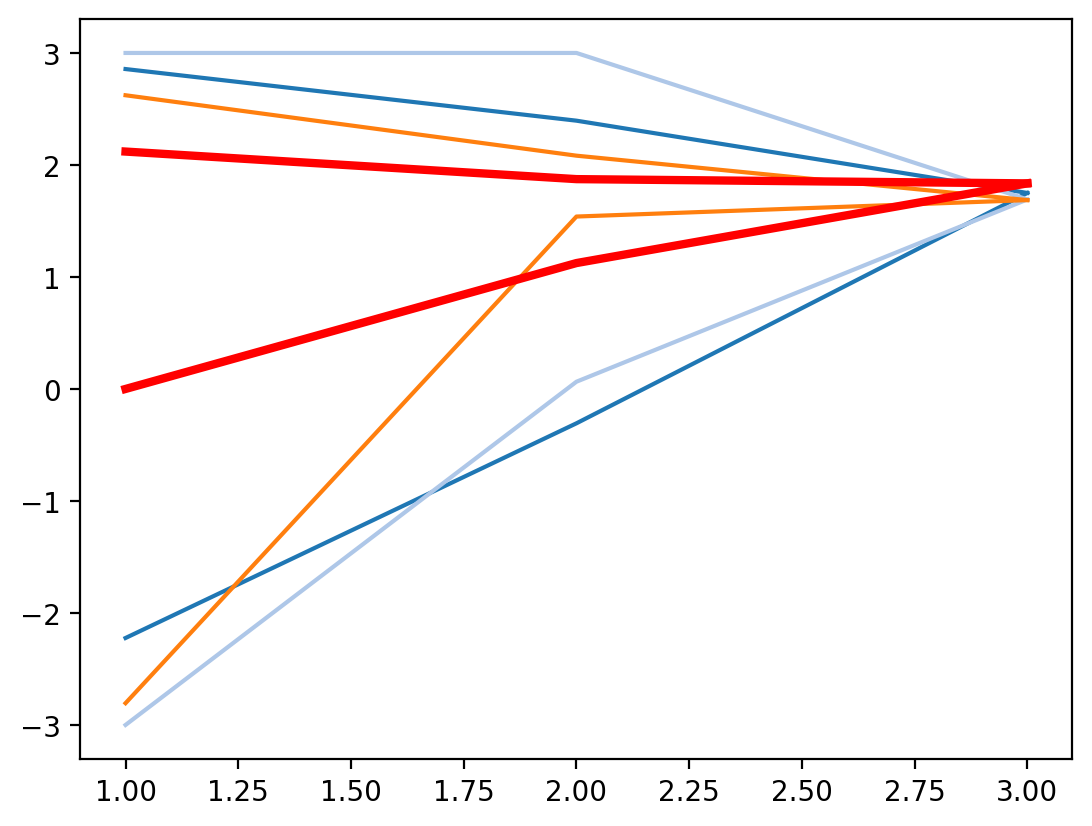

In [ ]:
_fig, _ax = plt.subplots()

for _i in range(bounds_run4_best.shape[0]):
    _ax.plot([1,2,3], bounds_run4_best.loc[_i, ["upper1", "upper2", "upper3"]], color = colors[_i])
    _ax.plot([1,2,3], bounds_run4_best.loc[_i, ["lower1", "lower2","upper3"]], color = colors[_i])

_ax.plot([1,2,3], [2.119577478632703, 1.873459510489336, 1.8356079417852893], lw=3, color="red")
_ax.plot([1,2,3], [0.0000000000000006285533994301576, 1.1240757062936024, 1.8356079417852893], lw=3, color="red")

_fig

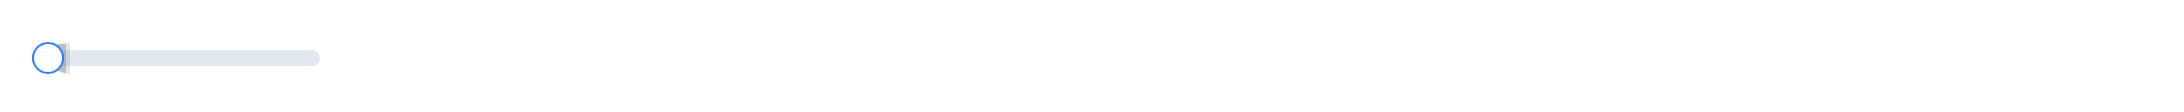

In [ ]:
slider9 = mo.ui.slider(start=0, stop=bounds_run4_best.shape[0]-1, step=1)
slider9

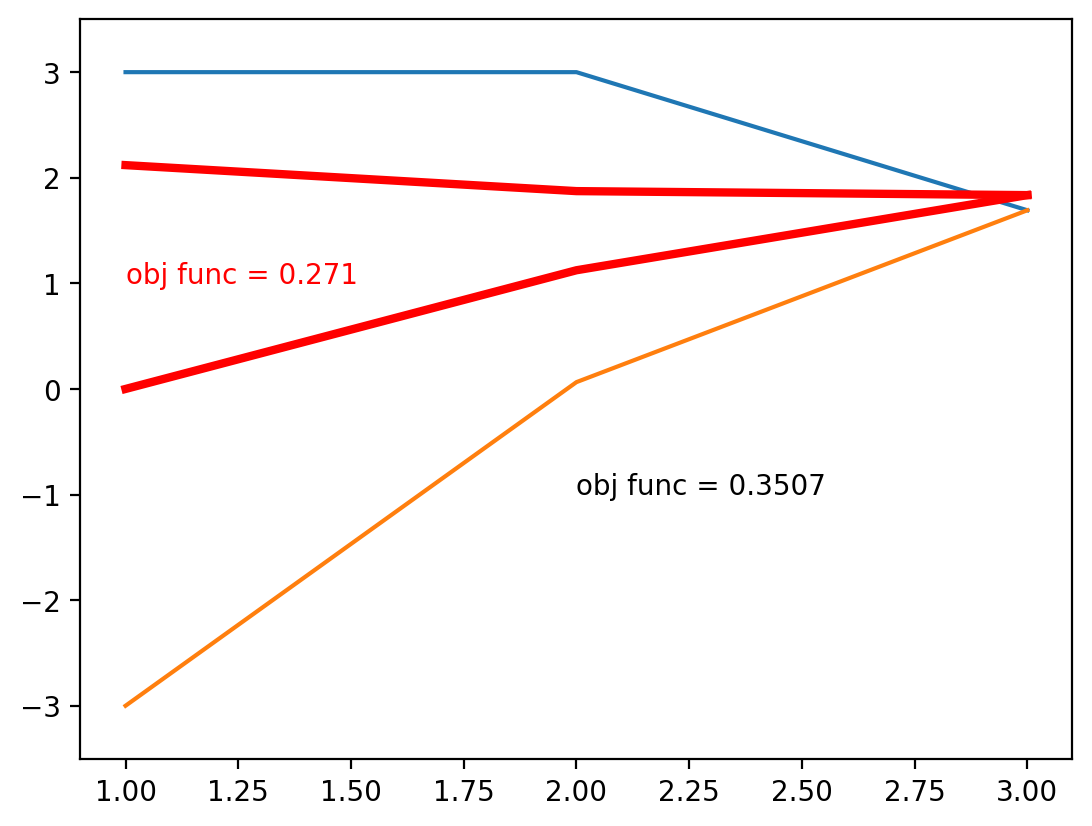

In [ ]:
plt.plot([1,2,3], bounds_run4_best.loc[slider9.value, ["upper1", "upper2", "upper3"]])
plt.plot([1,2,3], bounds_run4_best.loc[slider9.value, ["lower1", "lower2","upper3"]])

plt.plot([1,2,3], [2.119577478632703, 1.873459510489336, 1.8356079417852893], lw=3, color="red")
plt.plot([1,2,3], [0.0000000000000006285533994301576, 1.1240757062936024, 1.8356079417852893], lw=3, color="red")
plt.text(1, 1, str("obj func = 0.271"), color = "red")

plt.text(2, -1, str("obj func = ")+str(bounds_run4_best.loc[slider9.value, "obj_f"].round(4)))

plt.ylim(-3.5, 3.5)

plt.show()

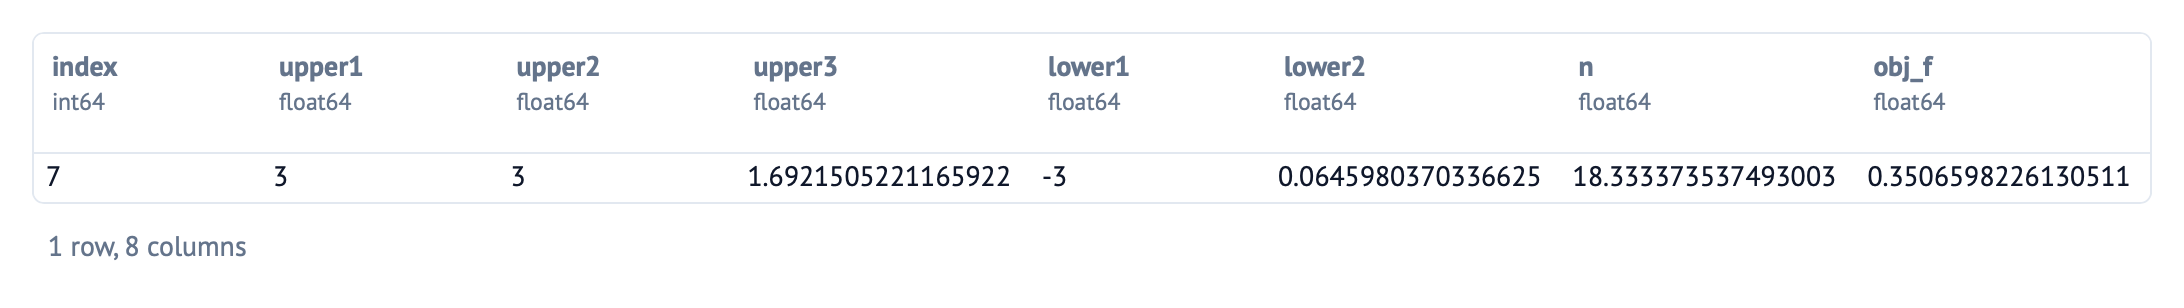

In [ ]:
bounds_run4_best[bounds_run4_best["obj_f"] < 0.38]

In [ ]:
sim.group_sequential_designs(
    n_analyses=3,
    upper_bounds=[3, 3, 1.6921505221165922],
    lower_bounds=[-3, 0.0645980370336625, 1.6921505221165922],
    n_patients=18.333373537493003,
    null_hypothesis=0,
    alt_hypothesis=1,
    variance=3
)